In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5070 Ti


In [2]:
pip install timm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
DATA_DIR = "/workspace/NIH"

for f in os.listdir(DATA_DIR):
    print(f)

images_010.zip
images_009.zip
images_008.zip
images_007.zip
images_006.zip
images_005.zip
images_004.zip
images_003.zip
images_002.zip
images_001.zip
images_011.zip
images_012.zip
Data_Entry_2017.csv
images
.ipynb_checkpoints
Project_II.py
train_val_list.txt
~
test_list.txt
best_convnextv2.pth
Test.ipynb
.Trash-0
best_efficientnetv2.pth
best_swin.pth
best_hybrid_v2.pth
best_residual_cnn.pth
best_hybrid_v3.pth
best_efficientnetv2_laam.pth
best_densenet121.pth
best_vit.pth
best_crossdense.pth
best_maxvit.pth
best_sedense_effnet_hybrid.pth
best_sedensenet121.pth
best_efficientnetv2_multiscale.pth


In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn

# ================= LOCAL DATA PATH =================
DATA_DIR = "/workspace/NIH"
CSV_PATH = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR  = os.path.join(DATA_DIR, "images")

# ================= LOAD CSV =================
df = pd.read_csv(CSV_PATH)
print("Total rows:", len(df))

# ================= MULTI-LABEL EXTRACTION =================
unique_labels = sorted(set(
    label for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

print("Detected Classes:", unique_labels)
print("Total classes:", len(unique_labels))

# ================= VERIFY IMAGE COUNT =================
print("Total images found:", len(os.listdir(IMG_DIR)))

Total rows: 112120
Detected Classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Total classes: 15
Total images found: 112120


In [5]:
import os
import pandas as pd

# ================= LOCAL PATH =================
DATA_DIR = "/workspace/NIH"
CSV_PATH = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR  = os.path.join(DATA_DIR, "images")

# ================= LOAD CSV =================
df = pd.read_csv(CSV_PATH)
print("Total rows:", len(df))

# ================= MULTI-LABEL EXPANSION =================
disease_labels = sorted(set(
    label for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

print("Total classes:", len(disease_labels))

# ================= SIMPLE IMAGE PATH FUNCTION =================
def find_image_path(img_name):
    return os.path.join(IMG_DIR, img_name)

Total rows: 112120
Total classes: 15


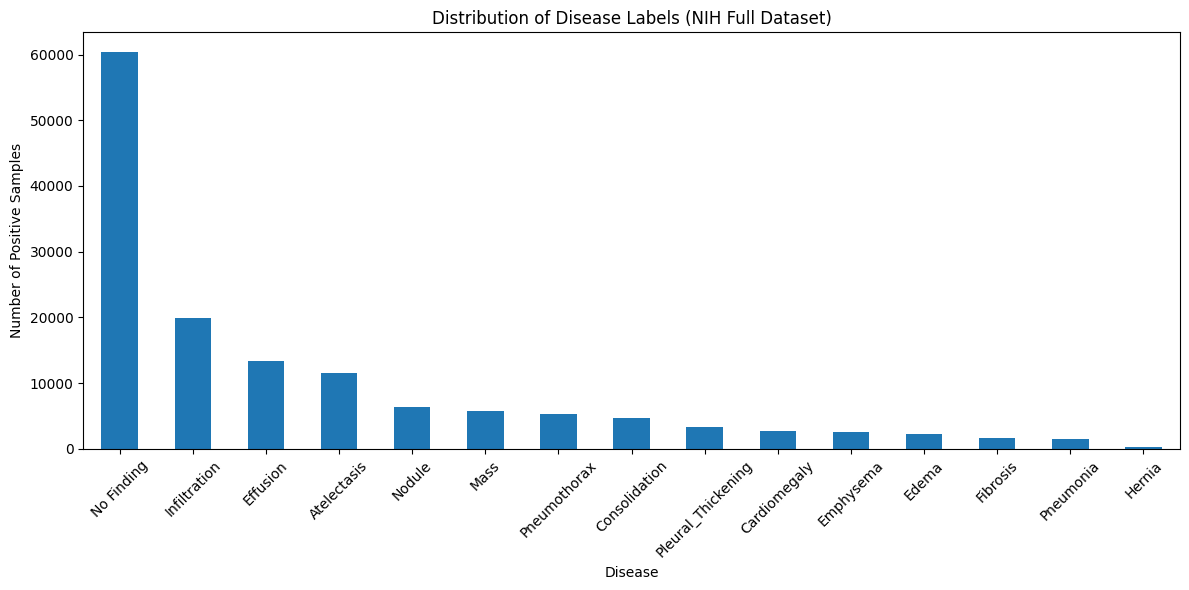

In [6]:
import matplotlib.pyplot as plt

# Count number of positive samples per disease
label_counts = df[disease_labels].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
label_counts.plot(kind='bar')

plt.title("Distribution of Disease Labels (NIH Full Dataset)")
plt.xlabel("Disease")
plt.ylabel("Number of Positive Samples")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [7]:
!pip install iterative-stratification

CLEAR MEMORY

In [ ]:
import torch
import gc

# Clear previous model from GPU memory
del model
del optimizer
del scheduler
del scaler
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared")
print(f"Memory allocated : {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory reserved  : {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

In [8]:
import torch, gc

# delete any old models sitting in memory
try: del model
except: pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1024**2:.0f} MB")

Free GPU memory: 15147 MB


In [ ]:
import torch
import gc

# Delete everything from previous run
del model
del optimizer
del scheduler
del scaler
del train_loader
del val_loader
del test_loader
gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared")
print(f"Memory allocated : {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory reserved  : {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

In [ ]:
import torch
import gc

# Only delete loaders — these are still in memory
del train_loader
del val_loader
del test_loader

gc.collect()
torch.cuda.empty_cache()

print("GPU memory cleared")
print(f"Memory allocated : {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Memory reserved  : {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

Efficient Net V2 with Graph Attention

In [9]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import timm

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
train_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

BATCH = 32

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)
val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)
test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== DISEASE GRAPH ATTENTION =====================
# Novel contribution: models co-occurrence relationships between chest diseases
# using a learnable adjacency matrix with attention-based propagation.
#
# Clinical motivation: chest diseases rarely occur in isolation.
# Atelectasis and Effusion frequently co-occur. Cardiomegaly often
# accompanies Edema. Hernia almost never co-occurs with other findings.
# A standard linear classifier treats all 15 output nodes independently,
# ignoring these co-occurrence patterns entirely.
#
# Mechanism:
#   - Learnable adjacency matrix A (15x15) initialized as identity
#   - Identity init = zero effect at epoch 0, cannot hurt baseline
#   - Softmax-normalized row-wise so each disease attends to all others
#   - Graph propagation: refined logits = original logits + A @ logits * alpha
#   - Learnable scalar alpha initialized to 0 — starts with zero contribution
#     and grows only if it helps, providing an additional safety guarantee
#
# The learned adjacency matrix after training is directly reportable:
# high off-diagonal values reveal which disease pairs the model learned
# to correlate — a clinically interpretable finding.

class DiseaseGraphAttention(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Adjacency matrix — identity init means no inter-disease influence at start
        self.A     = nn.Parameter(torch.eye(num_classes))
        # Alpha scalar — zero init means graph contributes nothing at epoch 0
        # grows only if gradient signal supports it
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        # logits: (B, num_classes)
        # Normalize adjacency row-wise via softmax
        A_norm   = torch.softmax(self.A, dim=-1)          # (C, C)
        # Propagate: each disease node aggregates information from all others
        refined  = logits @ A_norm.t()                    # (B, C)
        # Residual connection with learned scalar gate
        return logits + torch.tanh(self.alpha) * refined  # (B, C)

    def get_adjacency(self):
        """Return normalized adjacency for reporting."""
        with torch.no_grad():
            return torch.softmax(self.A, dim=-1).cpu().numpy()


# ===================== MODEL — EfficientNetV2-M + Disease Graph Attention =====================
class EfficientNetV2Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_m',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        in_features      = self.backbone.num_features   # 1280
        self.dropout     = nn.Dropout(0.5)
        self.classifier  = nn.Linear(in_features, num_classes)
        # Graph attention applied after classifier — residual, zero-init safe
        self.graph_attn  = DiseaseGraphAttention(num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.classifier(x)
        x = self.graph_attn(x)   # residual — if alpha stays ~0, identical to baseline
        return x

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== SETUP =====================
model     = EfficientNetV2Classifier(NUM_CLASSES, pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_efficientnetv2_graph.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched],
                            milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params = sum(p.numel() for p in model.parameters())
graph_params = sum(p.numel() for p in model.graph_attn.parameters())
print(f"\nModel: EfficientNetV2-M + Disease Graph Attention")
print(f"Total parameters       : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")
print(f"Graph attention params : {graph_params:,} (adjacency {NUM_CLASSES}x{NUM_CLASSES} + alpha)")
print(f"Alpha init             : {model.graph_attn.alpha.item():.4f} (zero = no graph effect at start)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Alpha':<10}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    alpha_val  = torch.tanh(model.graph_attn.alpha).item()
    elapsed    = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}"
          f"{current_lr:<12.6f}{alpha_val:<10.4f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== LEARNED ADJACENCY (reportable finding) =====================
model.load_state_dict(torch.load(SAVE_PATH))
adj = model.graph_attn.get_adjacency()
alpha_final = torch.tanh(model.graph_attn.alpha).item()

print("\n" + "="*55)
print("  LEARNED GRAPH ALPHA (reportable finding)")
print("="*55)
print(f"  Final alpha : {alpha_final:.4f}")
print(f"  Interpretation: {'graph actively contributing' if alpha_final > 0.05 else 'graph contribution minimal — baseline dominant'}")
print("\n  Top 5 strongest learned disease correlations:")
np.fill_diagonal(adj, 0)  # remove self-loops for reporting
top_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            top_pairs.append((adj[i, j], disease_labels[i], disease_labels[j]))
top_pairs.sort(reverse=True)
for score, src, tgt in top_pairs[:5]:
    print(f"  {src:<25} → {tgt:<25} {score:.4f}")
print("="*55)

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda

Model: EfficientNetV2-M + Disease Graph Attention
Total parameters       : 52,877,797 (201.71 MB)
Graph attention params

Evaluation Block


PART 1 — Finding optimal thresholds on validation set...

Optimal thresholds per class:
  Atelectasis               0.80
  Cardiomegaly              0.85
  Consolidation             0.80
  Edema                     0.85
  Effusion                  0.80
  Emphysema                 0.85
  Fibrosis                  0.85
  Hernia                    0.85
  Infiltration              0.60
  Mass                      0.80
  No Finding                0.25
  Nodule                    0.80
  Pleural_Thickening        0.80
  Pneumonia                 0.85
  Pneumothorax              0.80

PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...

Class                        AUC  95% CI
-------------------------------------------------------
  Atelectasis             0.7754  (0.7676 - 0.7837)
  Cardiomegaly            0.8847  (0.8747 - 0.8950)
  Consolidation           0.7478  (0.7379 - 0.7585)
  Edema                   0.8454  (0.8340 - 0.8558)
  Effusion                0.8277  (0.8214 - 0.8

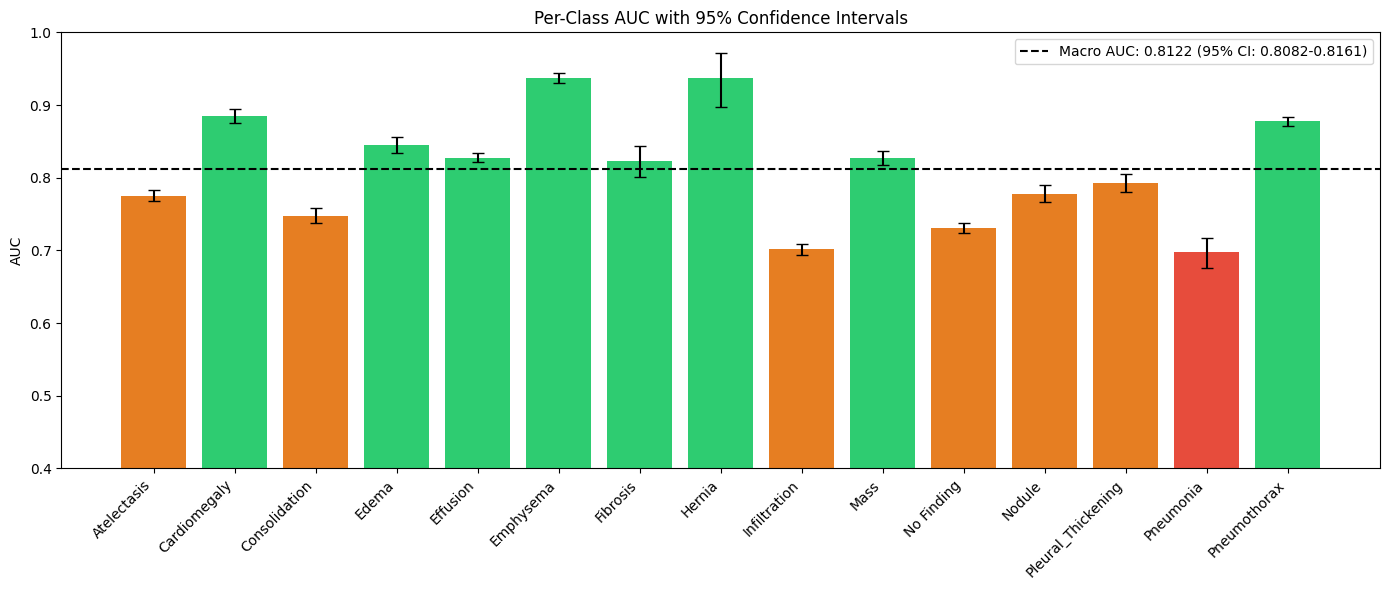

  Saved: per_class_auc.png


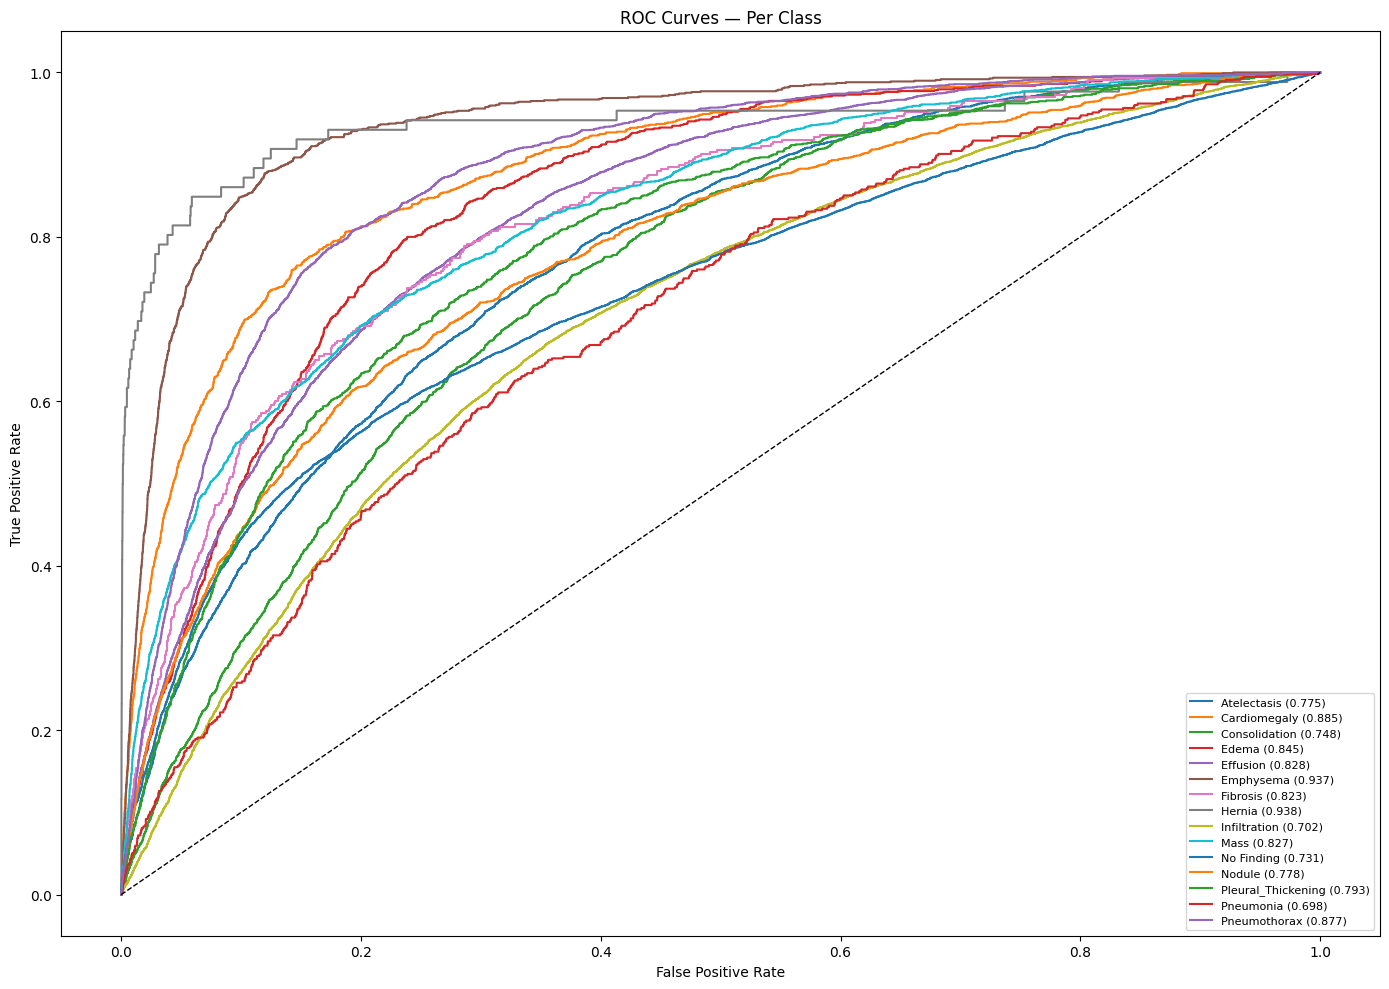

  Saved: roc_curves.png


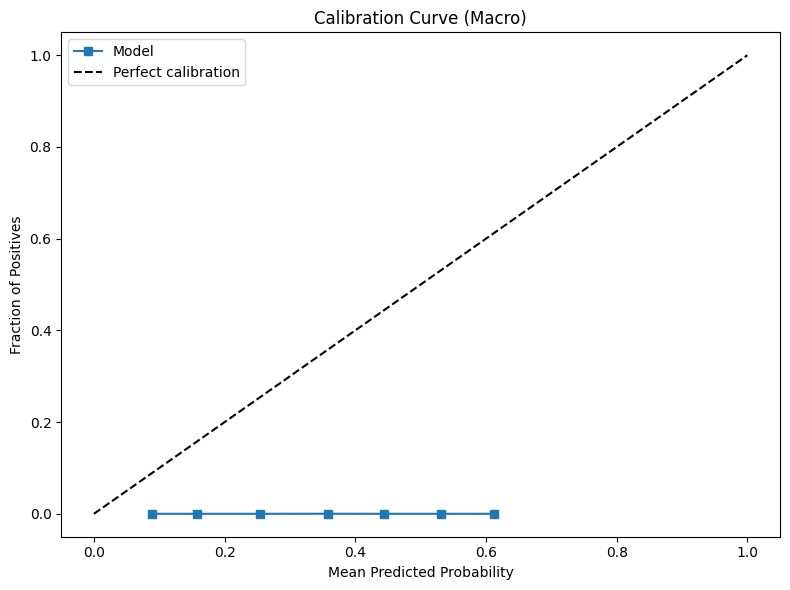

  Saved: calibration.png

PART 8 — Saving results to CSV...
  Saved: results.csv

  ALL EVALUATION COMPLETE
  Results saved to: /workspace/NIH/results

  Macro AUC : 0.8122 (95% CI: 0.8082 - 0.8161)
  Macro ECE : 0.2884
  Inference : 6.65 ms/image
  Params    : 52,877,797 (201.71 MB)


In [10]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, brier_score_loss)
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# ================================================================
#  COMPLETE EVALUATION BLOCK
#  Run this immediately after training finishes.
#  Requires: model, criterion, val_loader, test_loader,
#             disease_labels, NUM_CLASSES, device, all_t, all_o
#             (all_t and all_o from the test set in training script)
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_t = all_t.astype(np.float32)
all_o = all_o.astype(np.float32)
# ================================================================
# PART 1 — OPTIMAL THRESHOLDS FROM VALIDATION SET
# ================================================================
print("\n" + "="*60)
print("PART 1 — Finding optimal thresholds on validation set...")
print("="*60)

model.eval()
val_t, val_o = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        val_t.append(targets.cpu().numpy())
        val_o.append(torch.sigmoid(out).cpu().numpy())

val_t = np.vstack(val_t)
val_o = np.vstack(val_o)

val_t = val_t.astype(np.float32)
val_o = val_o.astype(np.float32)

thresholds = []
for i in range(NUM_CLASSES):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (val_o[:, i] >= t).astype(int)
        tp    = ((preds == 1) & (val_t[:, i] == 1)).sum()
        fp    = ((preds == 1) & (val_t[:, i] == 0)).sum()
        fn    = ((preds == 0) & (val_t[:, i] == 1)).sum()
        prec  = tp / (tp + fp + 1e-6)
        rec   = tp / (tp + fn + 1e-6)
        f1    = 2 * prec * rec / (prec + rec + 1e-6)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    thresholds.append(best_thresh)

print("\nOptimal thresholds per class:")
for label, t in zip(disease_labels, thresholds):
    print(f"  {label:<25} {t:.2f}")

# ================================================================
# PART 2 — PER-CLASS AUC WITH 95% CONFIDENCE INTERVALS
# ================================================================
print("\n" + "="*60)
print("PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...")
print("="*60)

N_BOOTSTRAP  = 1000
per_class_auc = roc_auc_score(all_t, all_o, average=None)
macro_auc     = roc_auc_score(all_t, all_o, average="macro")

# Bootstrap CI per class
ci_lower_list, ci_upper_list = [], []
macro_auc_boots = []

for _ in range(N_BOOTSTRAP):
    idx         = resample(np.arange(len(all_t)), random_state=None)
    boot_t      = all_t[idx]
    boot_o      = all_o[idx]
    # skip bootstrap sample if any class has only one label present
    if len(np.unique(boot_t)) < 2:
        continue
    try:
        boot_per_class = roc_auc_score(boot_t, boot_o, average=None)
        macro_auc_boots.append(roc_auc_score(boot_t, boot_o, average="macro"))
        ci_lower_list.append(boot_per_class)
        ci_upper_list.append(boot_per_class)
    except:
        continue

ci_lower_arr = np.percentile(ci_lower_list,  2.5, axis=0)
ci_upper_arr = np.percentile(ci_upper_list, 97.5, axis=0)
macro_ci_lo  = np.percentile(macro_auc_boots,  2.5)
macro_ci_hi  = np.percentile(macro_auc_boots, 97.5)

print(f"\n{'Class':<25} {'AUC':>6}  {'95% CI'}")
print("-"*55)
for i, label in enumerate(disease_labels):
    print(f"  {label:<23} {per_class_auc[i]:.4f}  ({ci_lower_arr[i]:.4f} - {ci_upper_arr[i]:.4f})")
print("-"*55)
print(f"  {'MACRO AVERAGE':<23} {macro_auc:.4f}  ({macro_ci_lo:.4f} - {macro_ci_hi:.4f})")

# ================================================================
# PART 3 — CLASSIFICATION REPORT
# ================================================================
print("\n" + "="*60)
print("PART 3 — Classification Report (optimal thresholds)...")
print("="*60)

test_preds = np.zeros(all_o.shape, dtype=np.float32)
for i in range(NUM_CLASSES):
    test_preds[:, i] = (all_o[:, i] >= thresholds[i]).astype(np.float32)

report = classification_report(all_t, test_preds,
                               target_names=disease_labels,
                               zero_division=0)
print(report)

# ================================================================
# PART 4 — CALIBRATION (ECE)
# ================================================================
print("\n" + "="*60)
print("PART 4 — Calibration (Expected Calibration Error)...")
print("="*60)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask       = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc    = y_true[mask].mean()
        bin_conf   = y_prob[mask].mean()
        ece       += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece_per_class = []
for i in range(NUM_CLASSES):
    ece = expected_calibration_error(all_t[:, i], all_o[:, i])
    ece_per_class.append(ece)
    print(f"  {disease_labels[i]:<25} ECE: {ece:.4f}")

print(f"\n  {'MACRO ECE':<25} ECE: {np.mean(ece_per_class):.4f}")

# ================================================================
# PART 5 — INFERENCE TIME
# ================================================================
print("\n" + "="*60)
print("PART 5 — Inference Time...")
print("="*60)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure
torch.cuda.synchronize()
start_inf = time.time()
N_RUNS    = 100
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy_input)
torch.cuda.synchronize()
elapsed_inf = (time.time() - start_inf) / N_RUNS * 1000  # ms

print(f"  Inference time per image : {elapsed_inf:.2f} ms")
print(f"  Throughput               : {1000/elapsed_inf:.1f} images/sec")

# ================================================================
# PART 6 — MODEL SIZE AND PARAMETERS
# ================================================================
print("\n" + "="*60)
print("PART 6 — Model Size & Parameters...")
print("="*60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (MB)      : {total_params * 4 / 1024**2:.2f}")

# ================================================================
# PART 7 — PLOTS
# ================================================================
print("\n" + "="*60)
print("PART 7 — Generating plots...")
print("="*60)

# --- 7a. Per-class AUC bar chart ---
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e67e22' if a >= 0.7 else '#e74c3c'
          for a in per_class_auc]
plt.bar(disease_labels, per_class_auc, color=colors,
        yerr=[per_class_auc - ci_lower_arr, ci_upper_arr - per_class_auc],
        capsize=4, error_kw={'linewidth': 1.5})
plt.axhline(y=macro_auc, color='black', linestyle='--',
            label=f'Macro AUC: {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f}-{macro_ci_hi:.4f})')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Per-Class AUC with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_auc.png'), dpi=150)
plt.show()
print("  Saved: per_class_auc.png")

# --- 7b. ROC curves ---
plt.figure(figsize=(14, 10))
for i, label in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(all_t[:, i], all_o[:, i])
    plt.plot(fpr, tpr, label=f"{label} ({per_class_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Class')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("  Saved: roc_curves.png")

# --- 7c. Calibration plot (macro) ---
plt.figure(figsize=(8, 6))
mean_prob = all_o.mean(axis=1)
mean_true = all_t.mean(axis=1)
fraction_pos, mean_pred = calibration_curve(
    (mean_true > 0.5).astype(int), mean_prob, n_bins=10)
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Macro)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()
print("  Saved: calibration.png")

# ================================================================
# PART 8 — SAVE ALL NUMBERS TO CSV FOR EASY REPORTING
# ================================================================
print("\n" + "="*60)
print("PART 8 — Saving results to CSV...")
print("="*60)

import pandas as pd

results_df = pd.DataFrame({
    'Class'         : disease_labels,
    'AUC'           : per_class_auc,
    'CI_Lower'      : ci_lower_arr,
    'CI_Upper'      : ci_upper_arr,
    'ECE'           : ece_per_class,
    'Threshold'     : thresholds
})

# Add macro row
macro_row = pd.DataFrame([{
    'Class'    : 'MACRO',
    'AUC'      : macro_auc,
    'CI_Lower' : macro_ci_lo,
    'CI_Upper' : macro_ci_hi,
    'ECE'      : np.mean(ece_per_class),
    'Threshold': '-'
}])

results_df = pd.concat([results_df, macro_row], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
print(f"  Saved: results.csv")

# Summary
print("\n" + "="*60)
print("  ALL EVALUATION COMPLETE")
print(f"  Results saved to: {RESULTS_DIR}")
print("="*60)
print(f"\n  Macro AUC : {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f} - {macro_ci_hi:.4f})")
print(f"  Macro ECE : {np.mean(ece_per_class):.4f}")
print(f"  Inference : {elapsed_inf:.2f} ms/image")
print(f"  Params    : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")


Saving Model

In [11]:
import os
import torch

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAME = "efficientnetv2_graph"

# ================================================================
# SAVE 1 — Full checkpoint
# ================================================================
full_ckpt_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_full_checkpoint.pth")
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : EPOCHS,
    'best_val_auc'        : best_val_auc,
    'num_classes'         : NUM_CLASSES,
    'disease_labels'      : disease_labels,
}, full_ckpt_path)
print(f"Full checkpoint saved : {full_ckpt_path}")
print(f"Size                  : {os.path.getsize(full_ckpt_path) / 1024**2:.2f} MB")

# ================================================================
# SAVE 2 — CPU weights
# ================================================================
cpu_weights_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_cpu_weights.pth")
cpu_state_dict   = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save(cpu_state_dict, cpu_weights_path)
print(f"\nCPU weights saved     : {cpu_weights_path}")
print(f"Size                  : {os.path.getsize(cpu_weights_path) / 1024**2:.2f} MB")

# ================================================================
# PORTABILITY CHECK
# ================================================================
print("\n" + "="*60)
print("PORTABILITY CHECK — Simulating laptop load (CPU only)...")
print("="*60)

model_cpu = EfficientNetV2Classifier(NUM_CLASSES, pretrained=False)
model_cpu.load_state_dict(
    torch.load(cpu_weights_path, map_location='cpu')
)
model_cpu.eval()

# Input size must be 384x384 to match training resolution
dummy = torch.randn(1, 3, 384, 384)
with torch.no_grad():
    output = model_cpu(dummy)

print(f"  Model loaded on CPU   : OK")
print(f"  Input shape           : {dummy.shape}")
print(f"  Output shape          : {output.shape}")
print(f"  Output (raw logits)   : {output.detach().numpy().round(4)}")
print(f"  Output (sigmoid)      : {torch.sigmoid(output).detach().numpy().round(4)}")
print("\n  Model is portable and runs correctly on CPU.")
print("  Safe to download and run on your laptop.")

# ================================================================
# PRINT DOWNLOAD INSTRUCTIONS
# ================================================================
print("\n" + "="*60)
print("  FILES TO DOWNLOAD FROM SERVER")
print("="*60)
print(f"\n  Folder to download : {RESULTS_DIR}")
print(f"\n  Contents:")
print(f"    {MODEL_NAME}_full_checkpoint.pth  — resume training / GPU inference")
print(f"    {MODEL_NAME}_cpu_weights.pth      — laptop inference (no GPU needed)")
print(f"    results.csv                        — all metrics")
print(f"    per_class_auc.png                  — AUC bar chart")
print(f"    roc_curves.png                     — ROC curves")
print(f"    calibration.png                    — calibration plot")
print(f"\n  To download from server to local machine, run this")
print(f"  in your LOCAL terminal (not inside Docker):")
print(f"\n    scp -r user@server_ip:{RESULTS_DIR} ~/Downloads/{MODEL_NAME}_results")
print("="*60)

Full checkpoint saved : /workspace/NIH/results/efficientnetv2_graph_full_checkpoint.pth
Size                  : 607.27 MB

CPU weights saved     : /workspace/NIH/results/efficientnetv2_graph_cpu_weights.pth
Size                  : 203.19 MB

PORTABILITY CHECK — Simulating laptop load (CPU only)...
  Model loaded on CPU   : OK
  Input shape           : torch.Size([1, 3, 384, 384])
  Output shape          : torch.Size([1, 15])
  Output (raw logits)   : [[-1.0806 -4.4776 -0.2489 -1.9826 -0.4313 -0.591  -2.7604 -0.7192 -0.692
  -0.8833  0.5383 -1.8549 -2.3591 -1.6344 -2.5942]]
  Output (sigmoid)      : [[0.2534 0.0112 0.4381 0.121  0.3938 0.3564 0.0595 0.3276 0.3336 0.2925
  0.6314 0.1353 0.0863 0.1632 0.0695]]

  Model is portable and runs correctly on CPU.
  Safe to download and run on your laptop.

  FILES TO DOWNLOAD FROM SERVER

  Folder to download : /workspace/NIH/results

  Contents:
    efficientnetv2_graph_full_checkpoint.pth  — resume training / GPU inference
    efficientnetv2_

Additional Output

  DISEASE GRAPH ATTENTION — FULL REPORT

  Final alpha : -0.0024
  Interpretation : Graph contribution minimal — baseline dominant

  FULL ADJACENCY MATRIX (row = source, col = target)
  Value = learned attention weight from source to target
                    Atelectasi  Cardiomega  Consolidat       Edema    Effusion   Emphysema    Fibrosis      Hernia  Infiltrati        Mass  No Finding      Nodule  Pleural_Th   Pneumonia  Pneumothor
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       Atelectasis      0.1592      0.0598      0.0607      0.0596      0.0614      0.0600      0.0598      0.0598      0.0604      0.0597      0.0602      0.0593      0.0601      0.0606      0.0594
      Cardiomegaly      0.0605      0.1657      0.0603      0.0601      0.0602      0.0587      0.0592      0.0595      0.0603      0.0584      0.0600      0.059

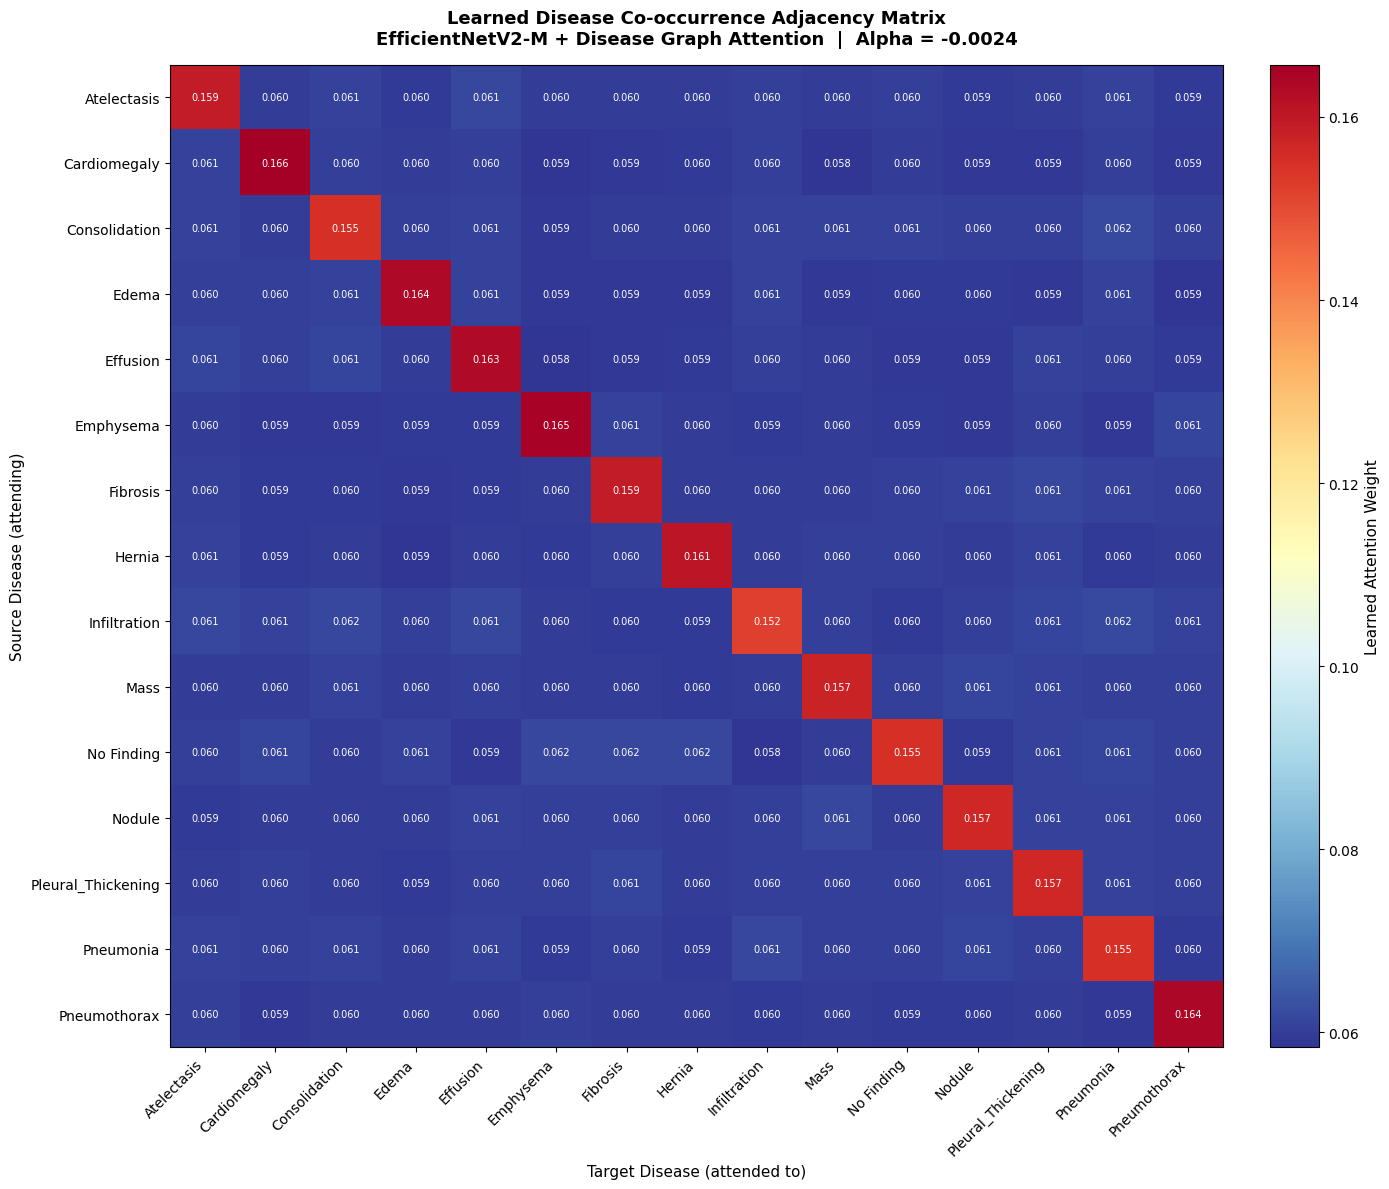


Heatmap saved : /workspace/NIH/results/disease_graph_adjacency_heatmap.png


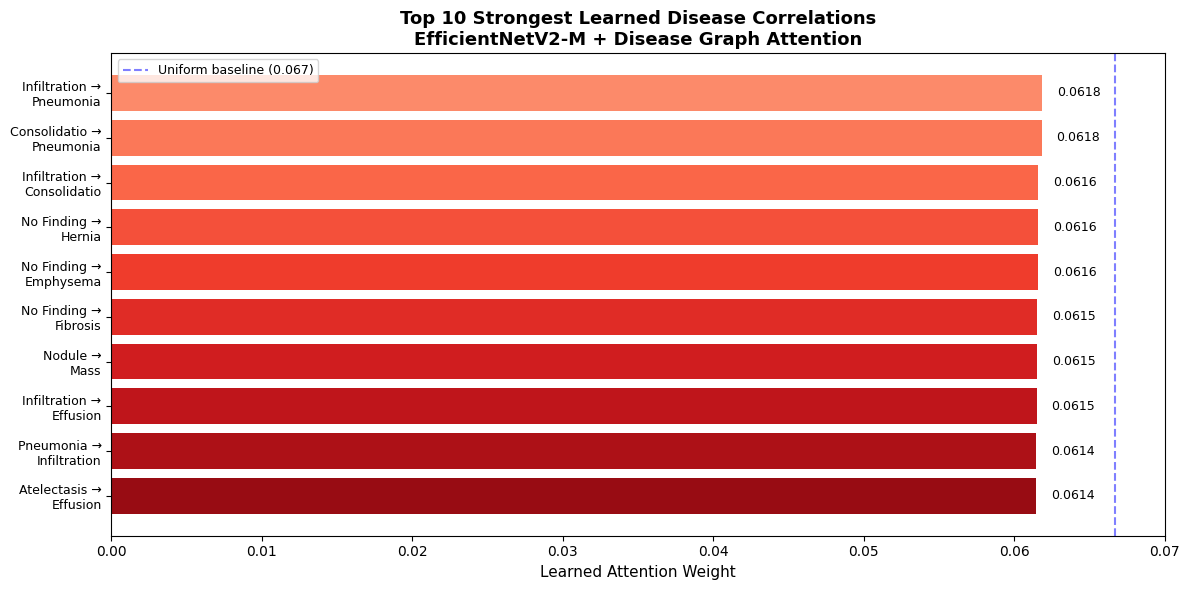

Bar chart saved : /workspace/NIH/results/disease_graph_top10_correlations.png

  SUMMARY FOR PAPER
  Alpha (graph contribution) : -0.0024
  Strongest correlation      : Infiltration → Pneumonia (0.0618)
  2nd strongest              : Consolidation → Pneumonia (0.0618)
  3rd strongest              : Infiltration → Consolidation (0.0616)

  Files saved to /workspace/NIH/results:
    disease_graph_adjacency_heatmap.png
    disease_graph_top10_correlations.png


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ================================================================
# LOAD BEST MODEL AND EXTRACT ADJACENCY
# ================================================================
model.load_state_dict(torch.load("/workspace/NIH/best_efficientnetv2_graph.pth"))
model.eval()

adj        = model.graph_attn.get_adjacency()   # (15, 15) numpy
alpha_final = torch.tanh(model.graph_attn.alpha).item()

print("="*60)
print("  DISEASE GRAPH ATTENTION — FULL REPORT")
print("="*60)
print(f"\n  Final alpha : {alpha_final:.4f}")
print(f"  Interpretation : {'Graph actively contributing to predictions' if alpha_final > 0.05 else 'Graph contribution minimal — baseline dominant'}")

# ================================================================
# FULL ADJACENCY MATRIX — printed as table
# ================================================================
print("\n" + "="*60)
print("  FULL ADJACENCY MATRIX (row = source, col = target)")
print("  Value = learned attention weight from source to target")
print("="*60)

# Print header
short_labels = [l[:10] for l in disease_labels]
header = f"{'':>18}" + "".join(f"{l:>12}" for l in short_labels)
print(header)
print("-" * (18 + 12 * len(disease_labels)))

for i, label in enumerate(disease_labels):
    row = f"{label:>18}" + "".join(f"{adj[i,j]:>12.4f}" for j in range(len(disease_labels)))
    print(row)

# ================================================================
# TOP 10 STRONGEST OFF-DIAGONAL CORRELATIONS
# ================================================================
print("\n" + "="*60)
print("  TOP 10 STRONGEST LEARNED DISEASE CORRELATIONS")
print("  (off-diagonal only — self-loops excluded)")
print("="*60)

adj_no_diag = adj.copy()
np.fill_diagonal(adj_no_diag, 0)

top_pairs = []
for i in range(len(disease_labels)):
    for j in range(len(disease_labels)):
        if i != j:
            top_pairs.append((adj_no_diag[i, j], disease_labels[i], disease_labels[j]))

top_pairs.sort(reverse=True)

print(f"\n  {'Rank':<6}{'Source Disease':<28}{'Target Disease':<28}{'Weight':>8}")
print(f"  {'-'*4:<6}{'-'*26:<28}{'-'*26:<28}{'-'*8:>8}")
for rank, (score, src, tgt) in enumerate(top_pairs[:10], 1):
    print(f"  {rank:<6}{src:<28}{tgt:<28}{score:>8.4f}")

# ================================================================
# BOTTOM 5 WEAKEST CORRELATIONS (also reportable)
# ================================================================
print("\n" + "="*60)
print("  BOTTOM 5 WEAKEST LEARNED DISEASE CORRELATIONS")
print("  (diseases the model learned are independent)")
print("="*60)
print(f"\n  {'Rank':<6}{'Source Disease':<28}{'Target Disease':<28}{'Weight':>8}")
print(f"  {'-'*4:<6}{'-'*26:<28}{'-'*26:<28}{'-'*8:>8}")
for rank, (score, src, tgt) in enumerate(reversed(top_pairs[-5:]), 1):
    print(f"  {rank:<6}{src:<28}{tgt:<28}{score:>8.4f}")

# ================================================================
# HEATMAP — full adjacency matrix
# ================================================================
fig, ax = plt.subplots(figsize=(14, 12))

# Use a diverging colormap centered at 1/num_classes (uniform baseline)
uniform_val = 1.0 / len(disease_labels)
vmin        = adj.min()
vmax        = adj.max()

im = ax.imshow(adj, cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)

# Labels
ax.set_xticks(range(len(disease_labels)))
ax.set_yticks(range(len(disease_labels)))
ax.set_xticklabels(disease_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(disease_labels, fontsize=10)

# Annotate each cell with value
for i in range(len(disease_labels)):
    for j in range(len(disease_labels)):
        val      = adj[i, j]
        color    = 'white' if (val > 0.85*vmax or val < 0.15*vmax+vmin) else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=7, color=color)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Learned Attention Weight', fontsize=11)

ax.set_title(
    f'Learned Disease Co-occurrence Adjacency Matrix\n'
    f'EfficientNetV2-M + Disease Graph Attention  |  Alpha = {alpha_final:.4f}',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Target Disease (attended to)', fontsize=11)
ax.set_ylabel('Source Disease (attending)', fontsize=11)

plt.tight_layout()
heatmap_path = os.path.join(RESULTS_DIR, "disease_graph_adjacency_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nHeatmap saved : {heatmap_path}")

# ================================================================
# BAR CHART — top 10 correlations
# ================================================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

top10_scores = [p[0] for p in top_pairs[:10]]
top10_labels = [f"{p[1][:12]} →\n{p[2][:12]}" for p in top_pairs[:10]]
colors       = plt.cm.Reds(np.linspace(0.4, 0.9, 10))

bars = ax2.barh(range(10), top10_scores, color=colors)
ax2.set_yticks(range(10))
ax2.set_yticklabels(top10_labels, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Learned Attention Weight', fontsize=11)
ax2.set_title(
    'Top 10 Strongest Learned Disease Correlations\n'
    'EfficientNetV2-M + Disease Graph Attention',
    fontsize=13, fontweight='bold'
)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, top10_scores)):
    ax2.text(score + 0.001, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=9)

ax2.axvline(x=uniform_val, color='blue', linestyle='--', alpha=0.5,
            label=f'Uniform baseline ({uniform_val:.3f})')
ax2.legend(fontsize=9)

plt.tight_layout()
barchart_path = os.path.join(RESULTS_DIR, "disease_graph_top10_correlations.png")
plt.savefig(barchart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Bar chart saved : {barchart_path}")

print("\n" + "="*60)
print("  SUMMARY FOR PAPER")
print("="*60)
print(f"  Alpha (graph contribution) : {alpha_final:.4f}")
print(f"  Strongest correlation      : {top_pairs[0][1]} → {top_pairs[0][2]} ({top_pairs[0][0]:.4f})")
print(f"  2nd strongest              : {top_pairs[1][1]} → {top_pairs[1][2]} ({top_pairs[1][0]:.4f})")
print(f"  3rd strongest              : {top_pairs[2][1]} → {top_pairs[2][2]} ({top_pairs[2][0]:.4f})")
print(f"\n  Files saved to {RESULTS_DIR}:")
print(f"    disease_graph_adjacency_heatmap.png")
print(f"    disease_graph_top10_correlations.png")
print("="*60)

ViT

In [9]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import timm

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
# ViT-B/16 requires 224x224 — patch size is 16x16
# giving 14x14 = 196 patches per image
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

# ViT-B/16 has 86M params — batch 32 safe on 16GB VRAM
BATCH = 32

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)

val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== MODEL — ViT-Base/16 =====================
class ViTClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0,        # remove default head
            global_pool='token'   # use CLS token for classification
        )
        in_features     = self.backbone.num_features   # 768 for ViT-B
        self.dropout    = nn.Dropout(0.5)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== SETUP =====================
model     = ViTClassifier(NUM_CLASSES, pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)
EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_vit.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: ViT-Base/16 (pretrained ImageNet)")
print(f"Total parameters : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}{current_lr:<12.6f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda



Model: ViT-Base/16 (pretrained ImageNet)
Total parameters : 85,810,191 (327.34 MB)

Epoch   Train Loss    Val Loss    Val AUC     LR          Time
1       1.2054        1.0869      0.7386      0.000003    179s <-- best saved
2       1.1143        1.0384      0.7771      0.000012    178s <-- best saved
3       1.0619        1.0158      0.7870      0.000021    176s <-- best saved
4       1.0463        1.0775      0.7651      0.000030    175s
5       1.0125        1.0239      0.7866      0.000030    174s
6       0.9812        1.0105      0.7960      0.000029    175s <-- best saved
7       0.9494        0.9792      0.8019      0.000028    175s <-- best saved
8       0.9148        1.0257      0.7947      0.000026    175s
9       0.8875        0.9821      0.8067      0.000024    175s <-- best saved
10      0.8495        0.9724      0.8126      0.000022    175s <-- best saved
11      0.8117        0.9845      0.8052      0.000019    174s
12      0.7719        1.0220      0.8105      0.000017

Evaluation Block


PART 1 — Finding optimal thresholds on validation set...

Optimal thresholds per class:
  Atelectasis               0.70
  Cardiomegaly              0.85
  Consolidation             0.80
  Edema                     0.85
  Effusion                  0.80
  Emphysema                 0.85
  Fibrosis                  0.85
  Hernia                    0.85
  Infiltration              0.50
  Mass                      0.75
  No Finding                0.35
  Nodule                    0.65
  Pleural_Thickening        0.70
  Pneumonia                 0.85
  Pneumothorax              0.85

PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...

Class                        AUC  95% CI
-------------------------------------------------------
  Atelectasis             0.7483  (0.7392 - 0.7568)
  Cardiomegaly            0.8818  (0.8718 - 0.8911)
  Consolidation           0.7439  (0.7334 - 0.7539)
  Edema                   0.8454  (0.8335 - 0.8570)
  Effusion                0.8063  (0.7998 - 0.8

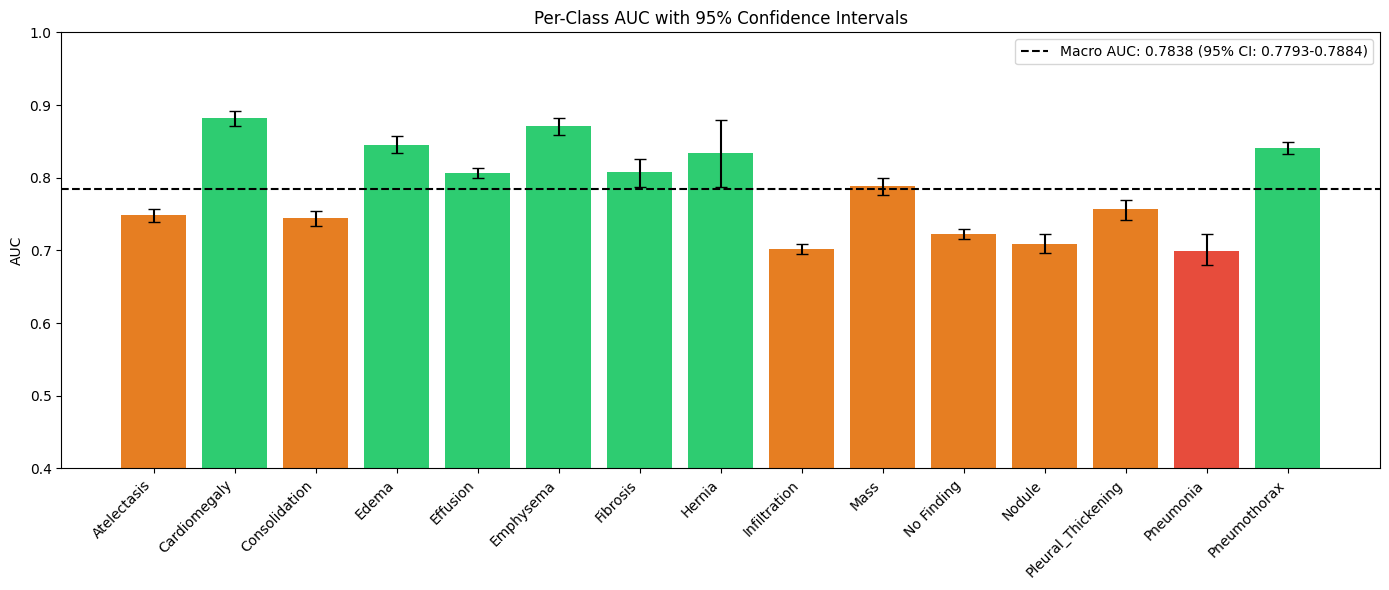

  Saved: per_class_auc.png


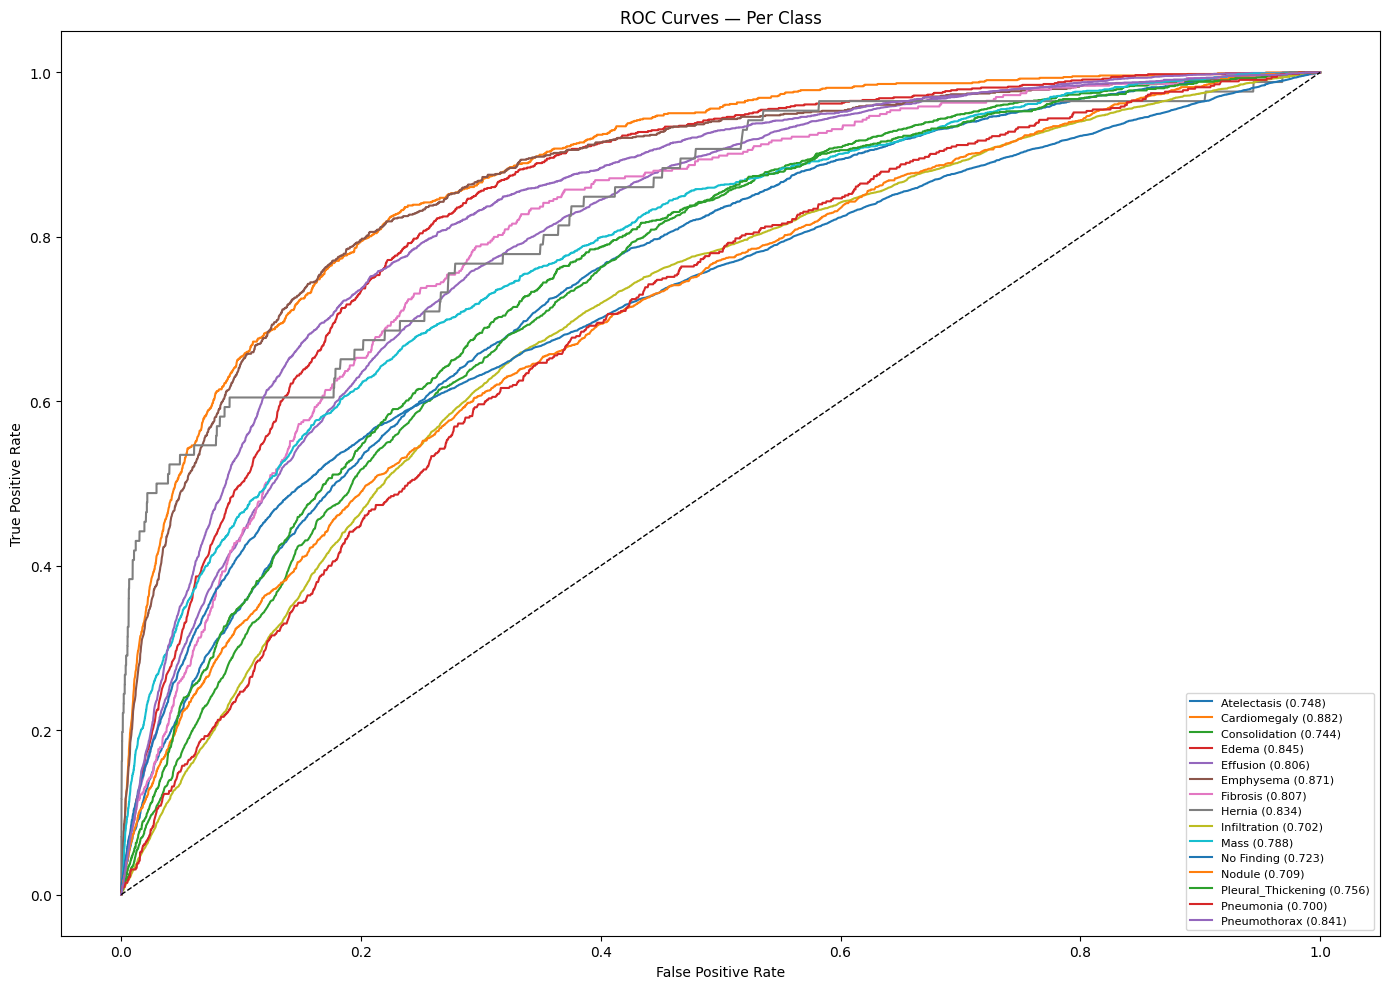

  Saved: roc_curves.png


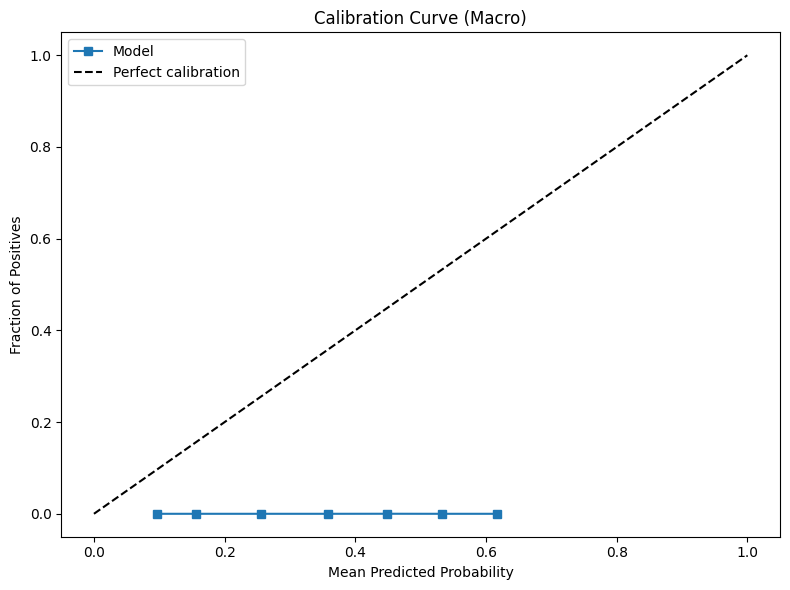

  Saved: calibration.png

PART 8 — Saving results to CSV...
  Saved: results.csv

  ALL EVALUATION COMPLETE
  Results saved to: /workspace/NIH/results

  Macro AUC : 0.7838 (95% CI: 0.7793 - 0.7884)
  Macro ECE : 0.3040
  Inference : 2.22 ms/image
  Params    : 85,810,191 (327.34 MB)


In [11]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, brier_score_loss)
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# ================================================================
#  COMPLETE EVALUATION BLOCK
#  Run this immediately after training finishes.
#  Requires: model, criterion, val_loader, test_loader,
#             disease_labels, NUM_CLASSES, device, all_t, all_o
#             (all_t and all_o from the test set in training script)
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_t = all_t.astype(np.float32)
all_o = all_o.astype(np.float32)
# ================================================================
# PART 1 — OPTIMAL THRESHOLDS FROM VALIDATION SET
# ================================================================
print("\n" + "="*60)
print("PART 1 — Finding optimal thresholds on validation set...")
print("="*60)

model.eval()
val_t, val_o = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        val_t.append(targets.cpu().numpy())
        val_o.append(torch.sigmoid(out).cpu().numpy())

val_t = np.vstack(val_t)
val_o = np.vstack(val_o)

val_t = val_t.astype(np.float32)
val_o = val_o.astype(np.float32)

thresholds = []
for i in range(NUM_CLASSES):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (val_o[:, i] >= t).astype(int)
        tp    = ((preds == 1) & (val_t[:, i] == 1)).sum()
        fp    = ((preds == 1) & (val_t[:, i] == 0)).sum()
        fn    = ((preds == 0) & (val_t[:, i] == 1)).sum()
        prec  = tp / (tp + fp + 1e-6)
        rec   = tp / (tp + fn + 1e-6)
        f1    = 2 * prec * rec / (prec + rec + 1e-6)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    thresholds.append(best_thresh)

print("\nOptimal thresholds per class:")
for label, t in zip(disease_labels, thresholds):
    print(f"  {label:<25} {t:.2f}")

# ================================================================
# PART 2 — PER-CLASS AUC WITH 95% CONFIDENCE INTERVALS
# ================================================================
print("\n" + "="*60)
print("PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...")
print("="*60)

N_BOOTSTRAP  = 1000
per_class_auc = roc_auc_score(all_t, all_o, average=None)
macro_auc     = roc_auc_score(all_t, all_o, average="macro")

# Bootstrap CI per class
ci_lower_list, ci_upper_list = [], []
macro_auc_boots = []

for _ in range(N_BOOTSTRAP):
    idx         = resample(np.arange(len(all_t)), random_state=None)
    boot_t      = all_t[idx]
    boot_o      = all_o[idx]
    # skip bootstrap sample if any class has only one label present
    if len(np.unique(boot_t)) < 2:
        continue
    try:
        boot_per_class = roc_auc_score(boot_t, boot_o, average=None)
        macro_auc_boots.append(roc_auc_score(boot_t, boot_o, average="macro"))
        ci_lower_list.append(boot_per_class)
        ci_upper_list.append(boot_per_class)
    except:
        continue

ci_lower_arr = np.percentile(ci_lower_list,  2.5, axis=0)
ci_upper_arr = np.percentile(ci_upper_list, 97.5, axis=0)
macro_ci_lo  = np.percentile(macro_auc_boots,  2.5)
macro_ci_hi  = np.percentile(macro_auc_boots, 97.5)

print(f"\n{'Class':<25} {'AUC':>6}  {'95% CI'}")
print("-"*55)
for i, label in enumerate(disease_labels):
    print(f"  {label:<23} {per_class_auc[i]:.4f}  ({ci_lower_arr[i]:.4f} - {ci_upper_arr[i]:.4f})")
print("-"*55)
print(f"  {'MACRO AVERAGE':<23} {macro_auc:.4f}  ({macro_ci_lo:.4f} - {macro_ci_hi:.4f})")

# ================================================================
# PART 3 — CLASSIFICATION REPORT
# ================================================================
print("\n" + "="*60)
print("PART 3 — Classification Report (optimal thresholds)...")
print("="*60)

test_preds = np.zeros(all_o.shape, dtype=np.float32)
for i in range(NUM_CLASSES):
    test_preds[:, i] = (all_o[:, i] >= thresholds[i]).astype(np.float32)

report = classification_report(all_t, test_preds,
                               target_names=disease_labels,
                               zero_division=0)
print(report)

# ================================================================
# PART 4 — CALIBRATION (ECE)
# ================================================================
print("\n" + "="*60)
print("PART 4 — Calibration (Expected Calibration Error)...")
print("="*60)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask       = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc    = y_true[mask].mean()
        bin_conf   = y_prob[mask].mean()
        ece       += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece_per_class = []
for i in range(NUM_CLASSES):
    ece = expected_calibration_error(all_t[:, i], all_o[:, i])
    ece_per_class.append(ece)
    print(f"  {disease_labels[i]:<25} ECE: {ece:.4f}")

print(f"\n  {'MACRO ECE':<25} ECE: {np.mean(ece_per_class):.4f}")

# ================================================================
# PART 5 — INFERENCE TIME
# ================================================================
print("\n" + "="*60)
print("PART 5 — Inference Time...")
print("="*60)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure
torch.cuda.synchronize()
start_inf = time.time()
N_RUNS    = 100
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy_input)
torch.cuda.synchronize()
elapsed_inf = (time.time() - start_inf) / N_RUNS * 1000  # ms

print(f"  Inference time per image : {elapsed_inf:.2f} ms")
print(f"  Throughput               : {1000/elapsed_inf:.1f} images/sec")

# ================================================================
# PART 6 — MODEL SIZE AND PARAMETERS
# ================================================================
print("\n" + "="*60)
print("PART 6 — Model Size & Parameters...")
print("="*60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (MB)      : {total_params * 4 / 1024**2:.2f}")

# ================================================================
# PART 7 — PLOTS
# ================================================================
print("\n" + "="*60)
print("PART 7 — Generating plots...")
print("="*60)

# --- 7a. Per-class AUC bar chart ---
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e67e22' if a >= 0.7 else '#e74c3c'
          for a in per_class_auc]
plt.bar(disease_labels, per_class_auc, color=colors,
        yerr=[per_class_auc - ci_lower_arr, ci_upper_arr - per_class_auc],
        capsize=4, error_kw={'linewidth': 1.5})
plt.axhline(y=macro_auc, color='black', linestyle='--',
            label=f'Macro AUC: {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f}-{macro_ci_hi:.4f})')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Per-Class AUC with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_auc.png'), dpi=150)
plt.show()
print("  Saved: per_class_auc.png")

# --- 7b. ROC curves ---
plt.figure(figsize=(14, 10))
for i, label in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(all_t[:, i], all_o[:, i])
    plt.plot(fpr, tpr, label=f"{label} ({per_class_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Class')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("  Saved: roc_curves.png")

# --- 7c. Calibration plot (macro) ---
plt.figure(figsize=(8, 6))
mean_prob = all_o.mean(axis=1)
mean_true = all_t.mean(axis=1)
fraction_pos, mean_pred = calibration_curve(
    (mean_true > 0.5).astype(int), mean_prob, n_bins=10)
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Macro)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()
print("  Saved: calibration.png")

# ================================================================
# PART 8 — SAVE ALL NUMBERS TO CSV FOR EASY REPORTING
# ================================================================
print("\n" + "="*60)
print("PART 8 — Saving results to CSV...")
print("="*60)

import pandas as pd

results_df = pd.DataFrame({
    'Class'         : disease_labels,
    'AUC'           : per_class_auc,
    'CI_Lower'      : ci_lower_arr,
    'CI_Upper'      : ci_upper_arr,
    'ECE'           : ece_per_class,
    'Threshold'     : thresholds
})

# Add macro row
macro_row = pd.DataFrame([{
    'Class'    : 'MACRO',
    'AUC'      : macro_auc,
    'CI_Lower' : macro_ci_lo,
    'CI_Upper' : macro_ci_hi,
    'ECE'      : np.mean(ece_per_class),
    'Threshold': '-'
}])

results_df = pd.concat([results_df, macro_row], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
print(f"  Saved: results.csv")

# Summary
print("\n" + "="*60)
print("  ALL EVALUATION COMPLETE")
print(f"  Results saved to: {RESULTS_DIR}")
print("="*60)
print(f"\n  Macro AUC : {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f} - {macro_ci_hi:.4f})")
print(f"  Macro ECE : {np.mean(ece_per_class):.4f}")
print(f"  Inference : {elapsed_inf:.2f} ms/image")
print(f"  Params    : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")


Model Saving

In [12]:
import os
import torch

# ================================================================
#  MODEL SAVE & PORTABILITY CHECK
#  Run after evaluation block.
#  Saves model in 2 formats + a CPU-compatible version for laptop.
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAME = "vit"   # change this per model you run

# ================================================================
# SAVE 1 — Full checkpoint (weights + optimizer + epoch info)
#           Use this if you want to resume training later
# ================================================================
full_ckpt_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_full_checkpoint.pth")
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : EPOCHS,
    'best_val_auc'        : best_val_auc,
    'num_classes'         : NUM_CLASSES,
    'disease_labels'      : disease_labels,
}, full_ckpt_path)
print(f"Full checkpoint saved : {full_ckpt_path}")
print(f"Size                  : {os.path.getsize(full_ckpt_path) / 1024**2:.2f} MB")

# ================================================================
# SAVE 2 — Weights only, mapped to CPU
#           Use this to load on your laptop without a GPU
# ================================================================
cpu_weights_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_cpu_weights.pth")
cpu_state_dict   = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save(cpu_state_dict, cpu_weights_path)
print(f"\nCPU weights saved     : {cpu_weights_path}")
print(f"Size                  : {os.path.getsize(cpu_weights_path) / 1024**2:.2f} MB")

# ================================================================
# PORTABILITY CHECK — Simulate loading on a CPU-only machine
#                     (exactly what your laptop will do)
# ================================================================
print("\n" + "="*60)
print("PORTABILITY CHECK — Simulating laptop load (CPU only)...")
print("="*60)

# Recreate model architecture on CPU
model_cpu  = ViTClassifier(NUM_CLASSES, pretrained=False)  # change class name per model
model_cpu.load_state_dict(
    torch.load(cpu_weights_path, map_location='cpu')
)
model_cpu.eval()

# Run one dummy forward pass on CPU
dummy    = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    output = model_cpu(dummy)

print(f"  Model loaded on CPU   : OK")
print(f"  Input shape           : {dummy.shape}")
print(f"  Output shape          : {output.shape}")
print(f"  Output (raw logits)   : {output.detach().numpy().round(4)}")
print(f"  Output (sigmoid)      : {torch.sigmoid(output).detach().numpy().round(4)}")
print("\n  Model is portable and runs correctly on CPU.")
print("  Safe to download and run on your laptop.")

# ================================================================
# PRINT DOWNLOAD INSTRUCTIONS
# ================================================================
print("\n" + "="*60)
print("  FILES TO DOWNLOAD FROM SERVER")
print("="*60)
print(f"\n  Folder to download : {RESULTS_DIR}")
print(f"\n  Contents:")
print(f"    {MODEL_NAME}_full_checkpoint.pth  — resume training / GPU inference")
print(f"    {MODEL_NAME}_cpu_weights.pth      — laptop inference (no GPU needed)")
print(f"    results.csv                        — all metrics")
print(f"    per_class_auc.png                  — AUC bar chart")
print(f"    roc_curves.png                     — ROC curves")
print(f"    calibration.png                    — calibration plot")
print(f"\n  To download from server to local machine, run this")
print(f"  in your LOCAL terminal (not inside Docker):")
print(f"\n    scp -r user@server_ip:{RESULTS_DIR} ~/Downloads/{MODEL_NAME}_results")
print("="*60)


Full checkpoint saved : /workspace/NIH/results/vit_full_checkpoint.pth
Size                  : 982.21 MB

CPU weights saved     : /workspace/NIH/results/vit_cpu_weights.pth
Size                  : 327.39 MB

PORTABILITY CHECK — Simulating laptop load (CPU only)...
  Model loaded on CPU   : OK
  Input shape           : torch.Size([1, 3, 224, 224])
  Output shape          : torch.Size([1, 15])
  Output (raw logits)   : [[-0.0036 -2.2733 -0.6392 -1.8095  0.013  -0.8761 -0.4633 -2.0115 -0.0347
  -0.8012 -0.246  -0.2371 -0.8814 -0.5765 -0.8825]]
  Output (sigmoid)      : [[0.4991 0.0934 0.3454 0.1407 0.5033 0.294  0.3862 0.118  0.4913 0.3098
  0.4388 0.441  0.2929 0.3597 0.2927]]

  Model is portable and runs correctly on CPU.
  Safe to download and run on your laptop.

  FILES TO DOWNLOAD FROM SERVER

  Folder to download : /workspace/NIH/results

  Contents:
    vit_full_checkpoint.pth  — resume training / GPU inference
    vit_cpu_weights.pth      — laptop inference (no GPU needed)
    r

DenseNet - 121

In [13]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import torchvision.models as models

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
# DenseNet-121 standard input is 224x224
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

# DenseNet-121 is lightweight at 8M params
# batch 64 is safe on 16GB VRAM
BATCH = 64

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)

val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== MODEL — DenseNet-121 =====================
class DenseNet121Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        # Load pretrained DenseNet-121 from torchvision
        # no timm needed — torchvision has it natively
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone        = models.densenet121(weights=weights)
        in_features          = self.backbone.classifier.in_features  # 1024
        # Replace classifier with dropout + linear for multilabel
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== SETUP =====================
model     = DenseNet121Classifier(NUM_CLASSES, pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_densenet121.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: DenseNet-121 (pretrained ImageNet)")
print(f"Total parameters : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}{current_lr:<12.6f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densene

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30.8M/30.8M [00:00<00:00, 68.6MB/s]


Model: DenseNet-121 (pretrained ImageNet)
Total parameters : 6,969,231 (26.59 MB)

Epoch   Train Loss    Val Loss    Val AUC     LR          Time


1       1.2695        1.1460      0.6997      0.000010    133s <-- best saved
2       1.1185        1.0358      0.7632      0.000040    137s <-- best saved
3       1.0409        0.9757      0.7935      0.000070    136s <-- best saved
4       0.9987        0.9755      0.7979      0.000100    138s <-- best saved
5       0.9624        0.9539      0.8070      0.000099    133s <-- best saved
6       0.9331        0.9471      0.8107      0.000097    134s <-- best saved
7       0.8981        0.9908      0.8052      0.000093    135s
8       0.8824        0.9479      0.8115      0.000087    135s <-- best saved
9       0.8632        1.0189      0.8012      0.000080    135s
10      0.8278        0.9358      0.8214      0.000073    135s <-- best saved
11      0.7941        0.9760      0.8129      0.000064    135s
12      0.7672        0.9870      0.8181      0.000055    139s
13      0.7291        0.9960      0.8190      0.000046    140s
14      0.6970        1.0555      0.8191      0.000037    136

Evaluation Block


PART 1 — Finding optimal thresholds on validation set...

Optimal thresholds per class:
  Atelectasis               0.60
  Cardiomegaly              0.85
  Consolidation             0.75
  Edema                     0.85
  Effusion                  0.75
  Emphysema                 0.85
  Fibrosis                  0.85
  Hernia                    0.85
  Infiltration              0.50
  Mass                      0.75
  No Finding                0.35
  Nodule                    0.70
  Pleural_Thickening        0.80
  Pneumonia                 0.80
  Pneumothorax              0.80

PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...

Class                        AUC  95% CI
-------------------------------------------------------
  Atelectasis             0.7584  (0.7498 - 0.7669)
  Cardiomegaly            0.8941  (0.8851 - 0.9028)
  Consolidation           0.7409  (0.7308 - 0.7510)
  Edema                   0.8403  (0.8295 - 0.8503)
  Effusion                0.8186  (0.8120 - 0.8

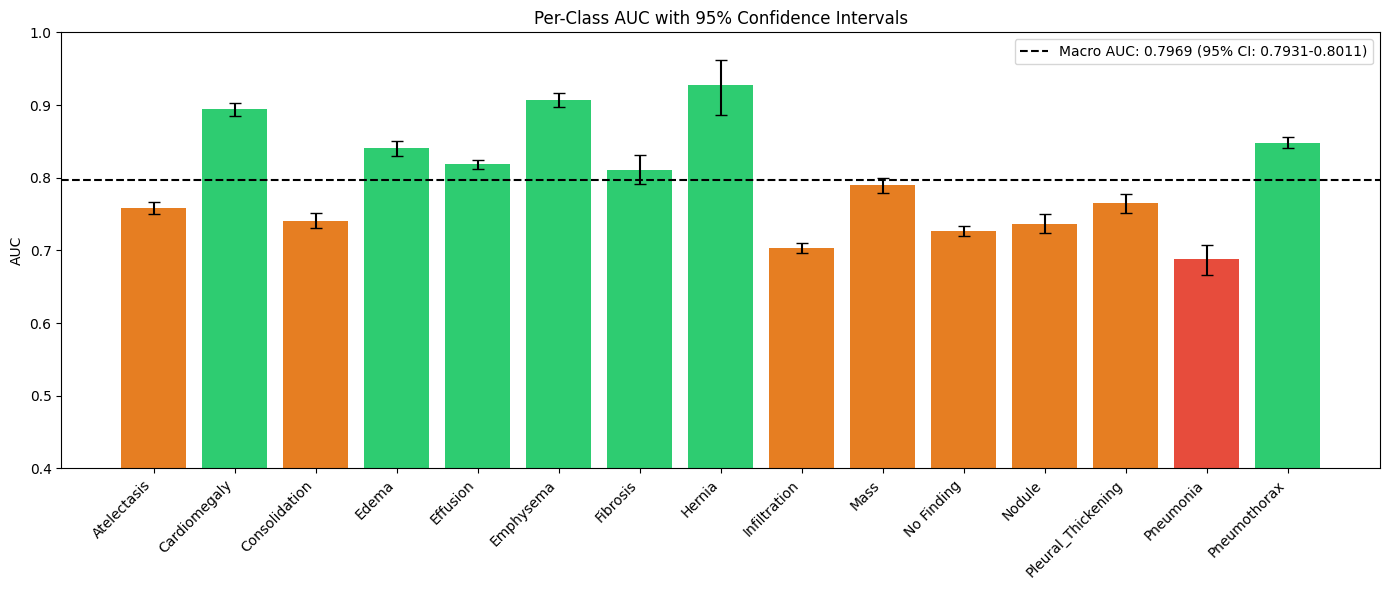

  Saved: per_class_auc.png


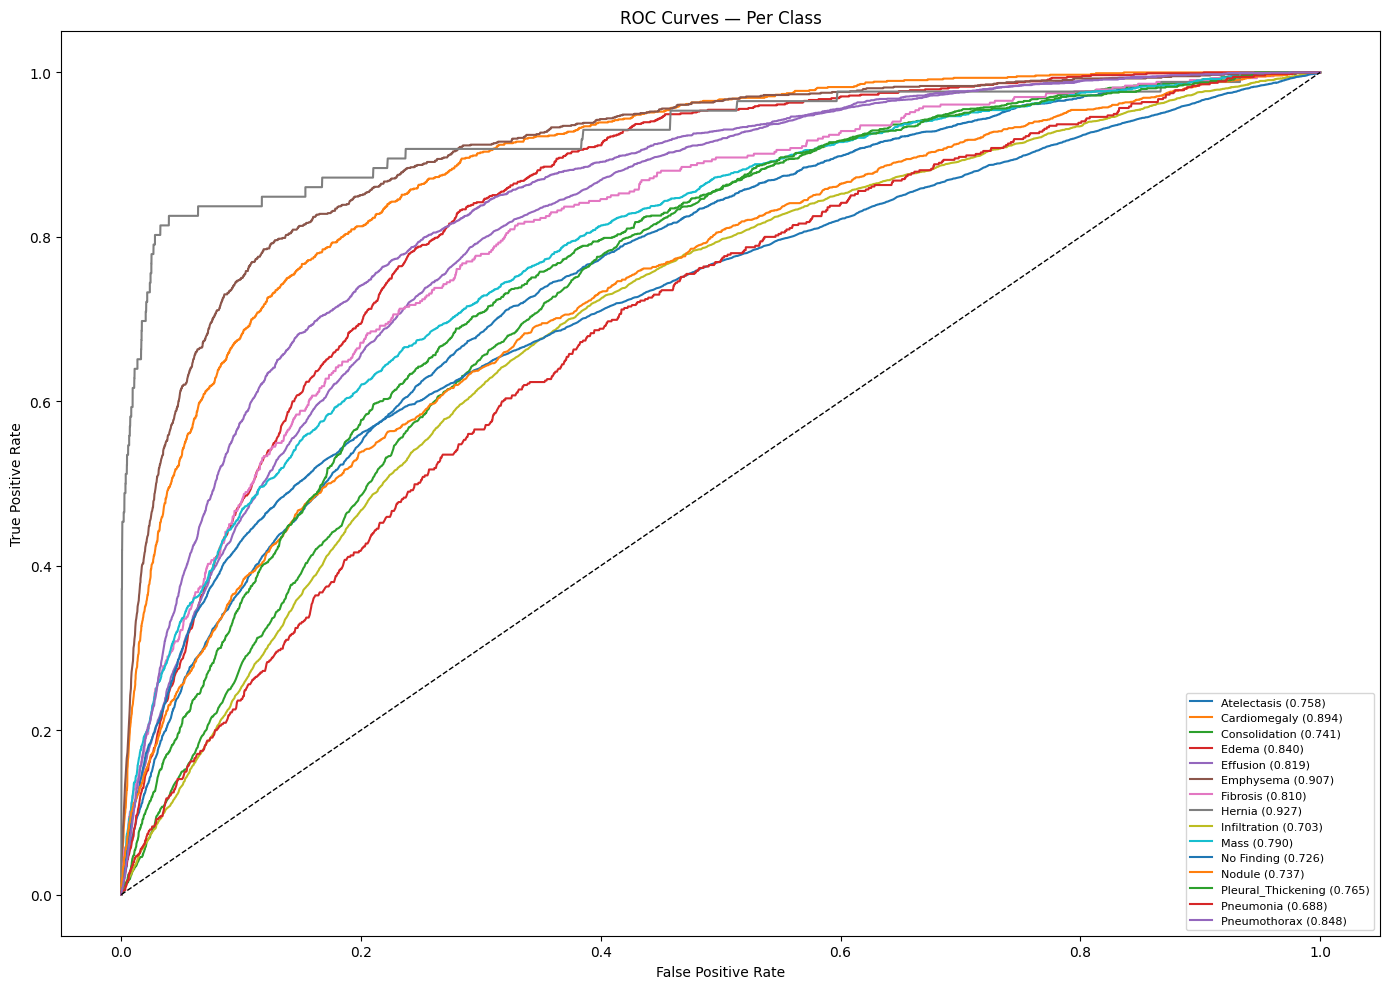

  Saved: roc_curves.png


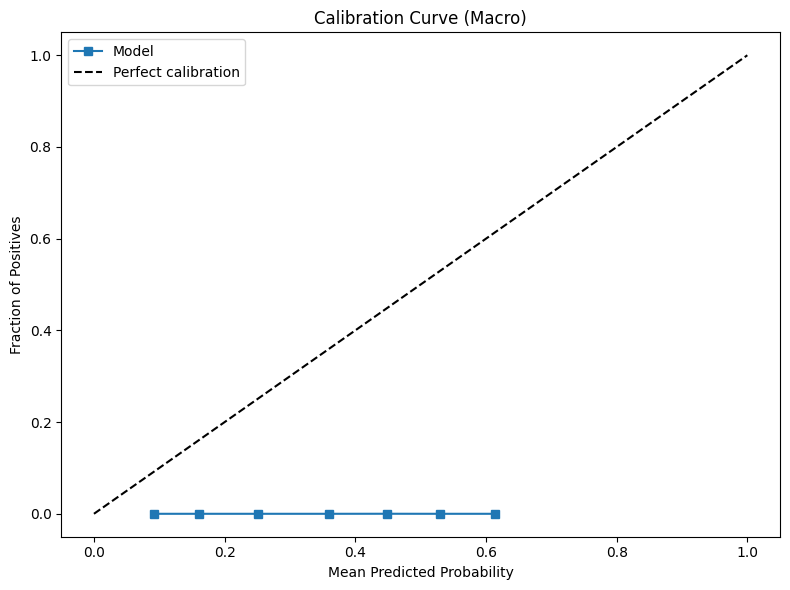

  Saved: calibration.png

PART 8 — Saving results to CSV...
  Saved: results.csv

  ALL EVALUATION COMPLETE
  Results saved to: /workspace/NIH/results

  Macro AUC : 0.7969 (95% CI: 0.7931 - 0.8011)
  Macro ECE : 0.3004
  Inference : 4.37 ms/image
  Params    : 6,969,231 (26.59 MB)


In [15]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, brier_score_loss)
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# ================================================================
#  COMPLETE EVALUATION BLOCK
#  Run this immediately after training finishes.
#  Requires: model, criterion, val_loader, test_loader,
#             disease_labels, NUM_CLASSES, device, all_t, all_o
#             (all_t and all_o from the test set in training script)
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_t = all_t.astype(np.float32)
all_o = all_o.astype(np.float32)
# ================================================================
# PART 1 — OPTIMAL THRESHOLDS FROM VALIDATION SET
# ================================================================
print("\n" + "="*60)
print("PART 1 — Finding optimal thresholds on validation set...")
print("="*60)

model.eval()
val_t, val_o = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        val_t.append(targets.cpu().numpy())
        val_o.append(torch.sigmoid(out).cpu().numpy())

val_t = np.vstack(val_t)
val_o = np.vstack(val_o)

val_t = val_t.astype(np.float32)
val_o = val_o.astype(np.float32)

thresholds = []
for i in range(NUM_CLASSES):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (val_o[:, i] >= t).astype(int)
        tp    = ((preds == 1) & (val_t[:, i] == 1)).sum()
        fp    = ((preds == 1) & (val_t[:, i] == 0)).sum()
        fn    = ((preds == 0) & (val_t[:, i] == 1)).sum()
        prec  = tp / (tp + fp + 1e-6)
        rec   = tp / (tp + fn + 1e-6)
        f1    = 2 * prec * rec / (prec + rec + 1e-6)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    thresholds.append(best_thresh)

print("\nOptimal thresholds per class:")
for label, t in zip(disease_labels, thresholds):
    print(f"  {label:<25} {t:.2f}")

# ================================================================
# PART 2 — PER-CLASS AUC WITH 95% CONFIDENCE INTERVALS
# ================================================================
print("\n" + "="*60)
print("PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...")
print("="*60)

N_BOOTSTRAP  = 1000
per_class_auc = roc_auc_score(all_t, all_o, average=None)
macro_auc     = roc_auc_score(all_t, all_o, average="macro")

# Bootstrap CI per class
ci_lower_list, ci_upper_list = [], []
macro_auc_boots = []

for _ in range(N_BOOTSTRAP):
    idx         = resample(np.arange(len(all_t)), random_state=None)
    boot_t      = all_t[idx]
    boot_o      = all_o[idx]
    # skip bootstrap sample if any class has only one label present
    if len(np.unique(boot_t)) < 2:
        continue
    try:
        boot_per_class = roc_auc_score(boot_t, boot_o, average=None)
        macro_auc_boots.append(roc_auc_score(boot_t, boot_o, average="macro"))
        ci_lower_list.append(boot_per_class)
        ci_upper_list.append(boot_per_class)
    except:
        continue

ci_lower_arr = np.percentile(ci_lower_list,  2.5, axis=0)
ci_upper_arr = np.percentile(ci_upper_list, 97.5, axis=0)
macro_ci_lo  = np.percentile(macro_auc_boots,  2.5)
macro_ci_hi  = np.percentile(macro_auc_boots, 97.5)

print(f"\n{'Class':<25} {'AUC':>6}  {'95% CI'}")
print("-"*55)
for i, label in enumerate(disease_labels):
    print(f"  {label:<23} {per_class_auc[i]:.4f}  ({ci_lower_arr[i]:.4f} - {ci_upper_arr[i]:.4f})")
print("-"*55)
print(f"  {'MACRO AVERAGE':<23} {macro_auc:.4f}  ({macro_ci_lo:.4f} - {macro_ci_hi:.4f})")

# ================================================================
# PART 3 — CLASSIFICATION REPORT
# ================================================================
print("\n" + "="*60)
print("PART 3 — Classification Report (optimal thresholds)...")
print("="*60)

test_preds = np.zeros(all_o.shape, dtype=np.float32)
for i in range(NUM_CLASSES):
    test_preds[:, i] = (all_o[:, i] >= thresholds[i]).astype(np.float32)

report = classification_report(all_t, test_preds,
                               target_names=disease_labels,
                               zero_division=0)
print(report)

# ================================================================
# PART 4 — CALIBRATION (ECE)
# ================================================================
print("\n" + "="*60)
print("PART 4 — Calibration (Expected Calibration Error)...")
print("="*60)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask       = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc    = y_true[mask].mean()
        bin_conf   = y_prob[mask].mean()
        ece       += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece_per_class = []
for i in range(NUM_CLASSES):
    ece = expected_calibration_error(all_t[:, i], all_o[:, i])
    ece_per_class.append(ece)
    print(f"  {disease_labels[i]:<25} ECE: {ece:.4f}")

print(f"\n  {'MACRO ECE':<25} ECE: {np.mean(ece_per_class):.4f}")

# ================================================================
# PART 5 — INFERENCE TIME
# ================================================================
print("\n" + "="*60)
print("PART 5 — Inference Time...")
print("="*60)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure
torch.cuda.synchronize()
start_inf = time.time()
N_RUNS    = 100
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy_input)
torch.cuda.synchronize()
elapsed_inf = (time.time() - start_inf) / N_RUNS * 1000  # ms

print(f"  Inference time per image : {elapsed_inf:.2f} ms")
print(f"  Throughput               : {1000/elapsed_inf:.1f} images/sec")

# ================================================================
# PART 6 — MODEL SIZE AND PARAMETERS
# ================================================================
print("\n" + "="*60)
print("PART 6 — Model Size & Parameters...")
print("="*60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (MB)      : {total_params * 4 / 1024**2:.2f}")

# ================================================================
# PART 7 — PLOTS
# ================================================================
print("\n" + "="*60)
print("PART 7 — Generating plots...")
print("="*60)

# --- 7a. Per-class AUC bar chart ---
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e67e22' if a >= 0.7 else '#e74c3c'
          for a in per_class_auc]
plt.bar(disease_labels, per_class_auc, color=colors,
        yerr=[per_class_auc - ci_lower_arr, ci_upper_arr - per_class_auc],
        capsize=4, error_kw={'linewidth': 1.5})
plt.axhline(y=macro_auc, color='black', linestyle='--',
            label=f'Macro AUC: {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f}-{macro_ci_hi:.4f})')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Per-Class AUC with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_auc.png'), dpi=150)
plt.show()
print("  Saved: per_class_auc.png")

# --- 7b. ROC curves ---
plt.figure(figsize=(14, 10))
for i, label in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(all_t[:, i], all_o[:, i])
    plt.plot(fpr, tpr, label=f"{label} ({per_class_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Class')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("  Saved: roc_curves.png")

# --- 7c. Calibration plot (macro) ---
plt.figure(figsize=(8, 6))
mean_prob = all_o.mean(axis=1)
mean_true = all_t.mean(axis=1)
fraction_pos, mean_pred = calibration_curve(
    (mean_true > 0.5).astype(int), mean_prob, n_bins=10)
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Macro)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()
print("  Saved: calibration.png")

# ================================================================
# PART 8 — SAVE ALL NUMBERS TO CSV FOR EASY REPORTING
# ================================================================
print("\n" + "="*60)
print("PART 8 — Saving results to CSV...")
print("="*60)

import pandas as pd

results_df = pd.DataFrame({
    'Class'         : disease_labels,
    'AUC'           : per_class_auc,
    'CI_Lower'      : ci_lower_arr,
    'CI_Upper'      : ci_upper_arr,
    'ECE'           : ece_per_class,
    'Threshold'     : thresholds
})

# Add macro row
macro_row = pd.DataFrame([{
    'Class'    : 'MACRO',
    'AUC'      : macro_auc,
    'CI_Lower' : macro_ci_lo,
    'CI_Upper' : macro_ci_hi,
    'ECE'      : np.mean(ece_per_class),
    'Threshold': '-'
}])

results_df = pd.concat([results_df, macro_row], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
print(f"  Saved: results.csv")

# Summary
print("\n" + "="*60)
print("  ALL EVALUATION COMPLETE")
print(f"  Results saved to: {RESULTS_DIR}")
print("="*60)
print(f"\n  Macro AUC : {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f} - {macro_ci_hi:.4f})")
print(f"  Macro ECE : {np.mean(ece_per_class):.4f}")
print(f"  Inference : {elapsed_inf:.2f} ms/image")
print(f"  Params    : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")


Saving Model

In [16]:
import os
import torch

# ================================================================
#  MODEL SAVE & PORTABILITY CHECK
#  Run after evaluation block.
#  Saves model in 2 formats + a CPU-compatible version for laptop.
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAME = "densenet121"   # change this per model you run

# ================================================================
# SAVE 1 — Full checkpoint (weights + optimizer + epoch info)
#           Use this if you want to resume training later
# ================================================================
full_ckpt_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_full_checkpoint.pth")
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : EPOCHS,
    'best_val_auc'        : best_val_auc,
    'num_classes'         : NUM_CLASSES,
    'disease_labels'      : disease_labels,
}, full_ckpt_path)
print(f"Full checkpoint saved : {full_ckpt_path}")
print(f"Size                  : {os.path.getsize(full_ckpt_path) / 1024**2:.2f} MB")

# ================================================================
# SAVE 2 — Weights only, mapped to CPU
#           Use this to load on your laptop without a GPU
# ================================================================
cpu_weights_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_cpu_weights.pth")
cpu_state_dict   = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save(cpu_state_dict, cpu_weights_path)
print(f"\nCPU weights saved     : {cpu_weights_path}")
print(f"Size                  : {os.path.getsize(cpu_weights_path) / 1024**2:.2f} MB")

# ================================================================
# PORTABILITY CHECK — Simulate loading on a CPU-only machine
#                     (exactly what your laptop will do)
# ================================================================
print("\n" + "="*60)
print("PORTABILITY CHECK — Simulating laptop load (CPU only)...")
print("="*60)

# Recreate model architecture on CPU
model_cpu  = DenseNet121Classifier(NUM_CLASSES, pretrained=False)  # change class name per model
model_cpu.load_state_dict(
    torch.load(cpu_weights_path, map_location='cpu')
)
model_cpu.eval()

# Run one dummy forward pass on CPU
dummy    = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    output = model_cpu(dummy)

print(f"  Model loaded on CPU   : OK")
print(f"  Input shape           : {dummy.shape}")
print(f"  Output shape          : {output.shape}")
print(f"  Output (raw logits)   : {output.detach().numpy().round(4)}")
print(f"  Output (sigmoid)      : {torch.sigmoid(output).detach().numpy().round(4)}")
print("\n  Model is portable and runs correctly on CPU.")
print("  Safe to download and run on your laptop.")

# ================================================================
# PRINT DOWNLOAD INSTRUCTIONS
# ================================================================
print("\n" + "="*60)
print("  FILES TO DOWNLOAD FROM SERVER")
print("="*60)
print(f"\n  Folder to download : {RESULTS_DIR}")
print(f"\n  Contents:")
print(f"    {MODEL_NAME}_full_checkpoint.pth  — resume training / GPU inference")
print(f"    {MODEL_NAME}_cpu_weights.pth      — laptop inference (no GPU needed)")
print(f"    results.csv                        — all metrics")
print(f"    per_class_auc.png                  — AUC bar chart")
print(f"    roc_curves.png                     — ROC curves")
print(f"    calibration.png                    — calibration plot")
print(f"\n  To download from server to local machine, run this")
print(f"  in your LOCAL terminal (not inside Docker):")
print(f"\n    scp -r user@server_ip:{RESULTS_DIR} ~/Downloads/{MODEL_NAME}_results")
print("="*60)


Full checkpoint saved : /workspace/NIH/results/densenet121_full_checkpoint.pth
Size                  : 80.67 MB

CPU weights saved     : /workspace/NIH/results/densenet121_cpu_weights.pth
Size                  : 27.15 MB

PORTABILITY CHECK — Simulating laptop load (CPU only)...
  Model loaded on CPU   : OK
  Input shape           : torch.Size([1, 3, 224, 224])
  Output shape          : torch.Size([1, 15])
  Output (raw logits)   : [[-4.8800e-01 -1.6473e+00 -8.6800e-02  1.6520e-01 -8.7950e-01 -1.8247e+00
  -1.7582e+00 -3.8776e+00  8.6030e-01 -1.4443e+00  2.8000e-03  6.4820e-01
  -1.2240e-01 -2.0380e-01 -9.2140e-01]]
  Output (sigmoid)      : [[0.3804 0.1615 0.4783 0.5412 0.2933 0.1389 0.147  0.0203 0.7027 0.1909
  0.5007 0.6566 0.4694 0.4492 0.2847]]

  Model is portable and runs correctly on CPU.
  Safe to download and run on your laptop.

  FILES TO DOWNLOAD FROM SERVER

  Folder to download : /workspace/NIH/results

  Contents:
    densenet121_full_checkpoint.pth  — resume training /

In [ ]:
Custom CNN

In [10]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

BATCH = 64

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)

val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== MODEL =====================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, _, _ = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = F.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y

class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.bn1      = nn.BatchNorm2d(in_c)
        self.conv1    = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_c)
        self.conv2    = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.se       = SEBlock(out_c)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Conv2d(in_c, out_c, 1, stride, bias=False)

    def forward(self, x):
        out      = F.relu(self.bn1(x))
        shortcut = self.shortcut(x)
        out      = self.conv1(out)
        out      = self.conv2(F.relu(self.bn2(out)))
        out      = self.se(out)
        out     += shortcut
        return out

class RobustResidualCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, 2, 3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, 2, 1)
        )
        self.layer1 = self._make_layer(64,  64,  2, 1)
        self.layer2 = self._make_layer(64,  128, 2, 2)
        self.layer3 = self._make_layer(128, 256, 3, 2)
        self.layer4 = self._make_layer(256, 512, 3, 2)
        self.pool    = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(512, num_classes)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [ResidualBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# ===================== SETUP =====================
model     = RobustResidualCNN(NUM_CLASSES).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_residual_cnn.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: RobustResidualCNN")
print(f"Total parameters : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}{current_lr:<12.6f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda

Model: RobustResidualCNN
Total parameters : 17,213,687 (65.67 MB)

Epoch   Train Loss    Val Loss    Val AUC     LR     

Evaluation Block


PART 1 — Finding optimal thresholds on validation set...

Optimal thresholds per class:
  Atelectasis               0.60
  Cardiomegaly              0.85
  Consolidation             0.70
  Edema                     0.85
  Effusion                  0.70
  Emphysema                 0.75
  Fibrosis                  0.80
  Hernia                    0.85
  Infiltration              0.55
  Mass                      0.80
  No Finding                0.30
  Nodule                    0.65
  Pleural_Thickening        0.70
  Pneumonia                 0.75
  Pneumothorax              0.75

PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...

Class                        AUC  95% CI
-------------------------------------------------------
  Atelectasis             0.7089  (0.6999 - 0.7175)
  Cardiomegaly            0.8490  (0.8380 - 0.8601)
  Consolidation           0.6963  (0.6846 - 0.7067)
  Edema                   0.8116  (0.7992 - 0.8235)
  Effusion                0.7642  (0.7575 - 0.7

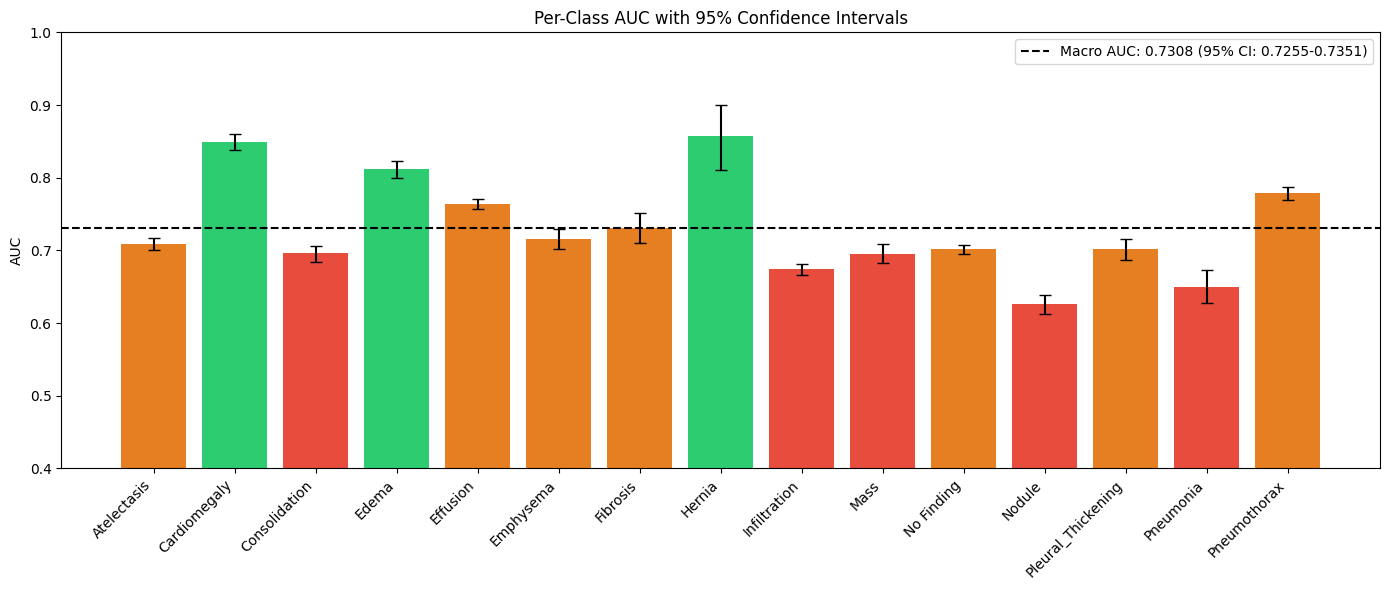

  Saved: per_class_auc.png


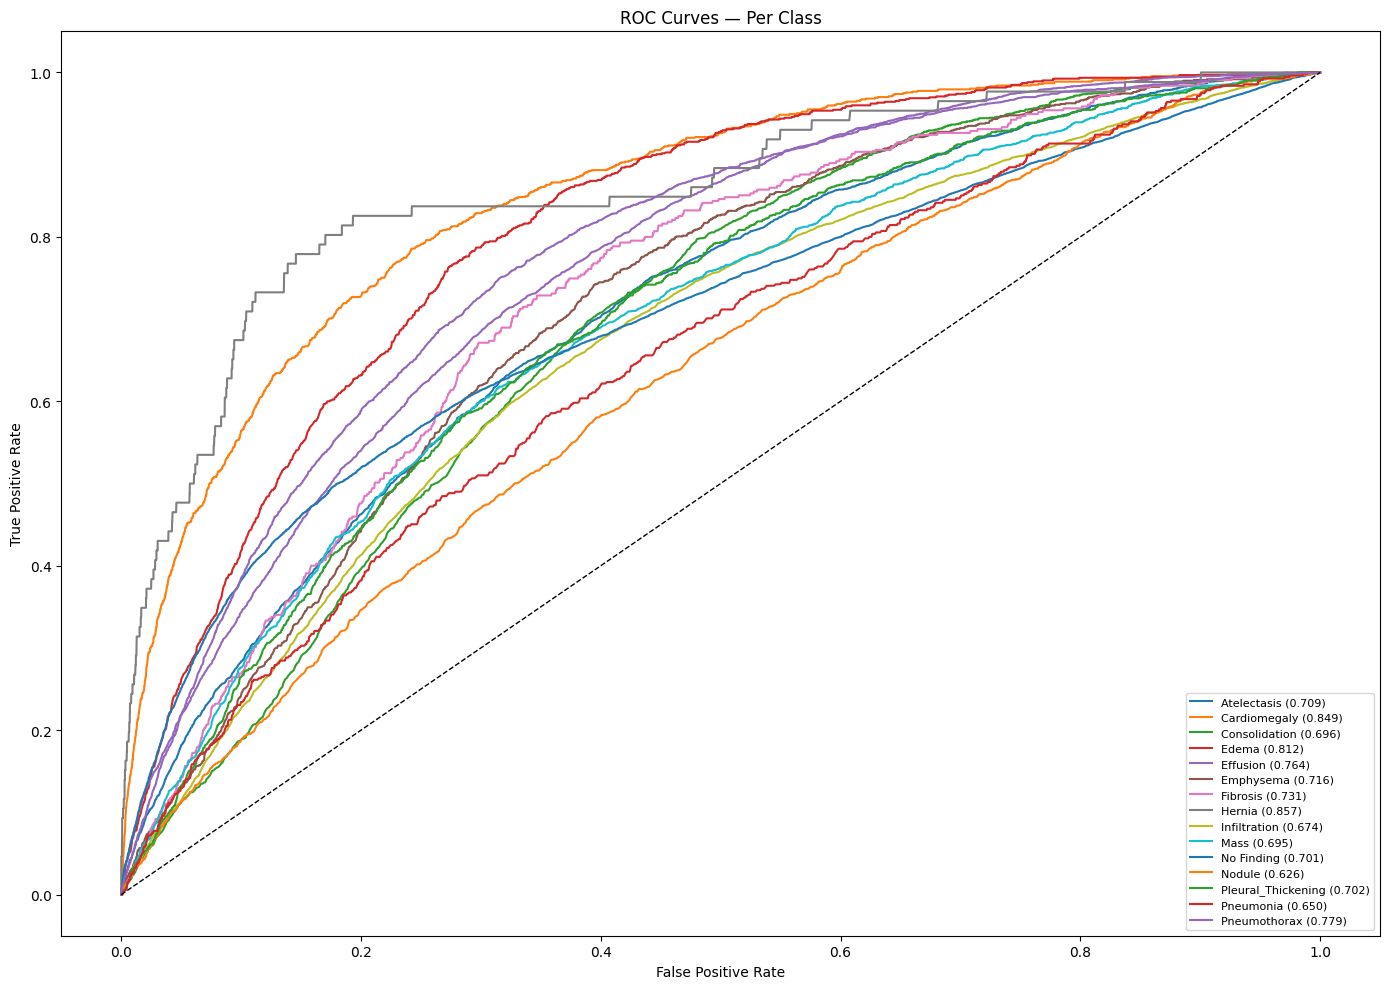

  Saved: roc_curves.png


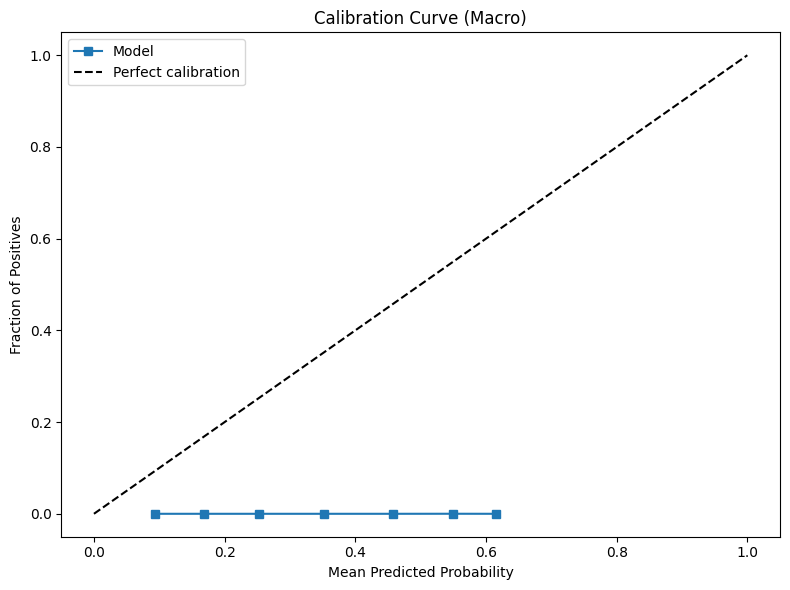

  Saved: calibration.png

PART 8 — Saving results to CSV...
  Saved: results.csv

  ALL EVALUATION COMPLETE
  Results saved to: /workspace/NIH/results

  Macro AUC : 0.7308 (95% CI: 0.7255 - 0.7351)
  Macro ECE : 0.3642
  Inference : 1.29 ms/image
  Params    : 17,213,687 (65.67 MB)


In [11]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, brier_score_loss)
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# ================================================================
#  COMPLETE EVALUATION BLOCK
#  Run this immediately after training finishes.
#  Requires: model, criterion, val_loader, test_loader,
#             disease_labels, NUM_CLASSES, device, all_t, all_o
#             (all_t and all_o from the test set in training script)
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_t = all_t.astype(np.float32)
all_o = all_o.astype(np.float32)
# ================================================================
# PART 1 — OPTIMAL THRESHOLDS FROM VALIDATION SET
# ================================================================
print("\n" + "="*60)
print("PART 1 — Finding optimal thresholds on validation set...")
print("="*60)

model.eval()
val_t, val_o = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        val_t.append(targets.cpu().numpy())
        val_o.append(torch.sigmoid(out).cpu().numpy())

val_t = np.vstack(val_t)
val_o = np.vstack(val_o)

val_t = val_t.astype(np.float32)
val_o = val_o.astype(np.float32)

thresholds = []
for i in range(NUM_CLASSES):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (val_o[:, i] >= t).astype(int)
        tp    = ((preds == 1) & (val_t[:, i] == 1)).sum()
        fp    = ((preds == 1) & (val_t[:, i] == 0)).sum()
        fn    = ((preds == 0) & (val_t[:, i] == 1)).sum()
        prec  = tp / (tp + fp + 1e-6)
        rec   = tp / (tp + fn + 1e-6)
        f1    = 2 * prec * rec / (prec + rec + 1e-6)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    thresholds.append(best_thresh)

print("\nOptimal thresholds per class:")
for label, t in zip(disease_labels, thresholds):
    print(f"  {label:<25} {t:.2f}")

# ================================================================
# PART 2 — PER-CLASS AUC WITH 95% CONFIDENCE INTERVALS
# ================================================================
print("\n" + "="*60)
print("PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...")
print("="*60)

N_BOOTSTRAP  = 1000
per_class_auc = roc_auc_score(all_t, all_o, average=None)
macro_auc     = roc_auc_score(all_t, all_o, average="macro")

# Bootstrap CI per class
ci_lower_list, ci_upper_list = [], []
macro_auc_boots = []

for _ in range(N_BOOTSTRAP):
    idx         = resample(np.arange(len(all_t)), random_state=None)
    boot_t      = all_t[idx]
    boot_o      = all_o[idx]
    # skip bootstrap sample if any class has only one label present
    if len(np.unique(boot_t)) < 2:
        continue
    try:
        boot_per_class = roc_auc_score(boot_t, boot_o, average=None)
        macro_auc_boots.append(roc_auc_score(boot_t, boot_o, average="macro"))
        ci_lower_list.append(boot_per_class)
        ci_upper_list.append(boot_per_class)
    except:
        continue

ci_lower_arr = np.percentile(ci_lower_list,  2.5, axis=0)
ci_upper_arr = np.percentile(ci_upper_list, 97.5, axis=0)
macro_ci_lo  = np.percentile(macro_auc_boots,  2.5)
macro_ci_hi  = np.percentile(macro_auc_boots, 97.5)

print(f"\n{'Class':<25} {'AUC':>6}  {'95% CI'}")
print("-"*55)
for i, label in enumerate(disease_labels):
    print(f"  {label:<23} {per_class_auc[i]:.4f}  ({ci_lower_arr[i]:.4f} - {ci_upper_arr[i]:.4f})")
print("-"*55)
print(f"  {'MACRO AVERAGE':<23} {macro_auc:.4f}  ({macro_ci_lo:.4f} - {macro_ci_hi:.4f})")

# ================================================================
# PART 3 — CLASSIFICATION REPORT
# ================================================================
print("\n" + "="*60)
print("PART 3 — Classification Report (optimal thresholds)...")
print("="*60)

test_preds = np.zeros(all_o.shape, dtype=np.float32)
for i in range(NUM_CLASSES):
    test_preds[:, i] = (all_o[:, i] >= thresholds[i]).astype(np.float32)

report = classification_report(all_t, test_preds,
                               target_names=disease_labels,
                               zero_division=0)
print(report)

# ================================================================
# PART 4 — CALIBRATION (ECE)
# ================================================================
print("\n" + "="*60)
print("PART 4 — Calibration (Expected Calibration Error)...")
print("="*60)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask       = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc    = y_true[mask].mean()
        bin_conf   = y_prob[mask].mean()
        ece       += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece_per_class = []
for i in range(NUM_CLASSES):
    ece = expected_calibration_error(all_t[:, i], all_o[:, i])
    ece_per_class.append(ece)
    print(f"  {disease_labels[i]:<25} ECE: {ece:.4f}")

print(f"\n  {'MACRO ECE':<25} ECE: {np.mean(ece_per_class):.4f}")

# ================================================================
# PART 5 — INFERENCE TIME
# ================================================================
print("\n" + "="*60)
print("PART 5 — Inference Time...")
print("="*60)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure
torch.cuda.synchronize()
start_inf = time.time()
N_RUNS    = 100
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy_input)
torch.cuda.synchronize()
elapsed_inf = (time.time() - start_inf) / N_RUNS * 1000  # ms

print(f"  Inference time per image : {elapsed_inf:.2f} ms")
print(f"  Throughput               : {1000/elapsed_inf:.1f} images/sec")

# ================================================================
# PART 6 — MODEL SIZE AND PARAMETERS
# ================================================================
print("\n" + "="*60)
print("PART 6 — Model Size & Parameters...")
print("="*60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (MB)      : {total_params * 4 / 1024**2:.2f}")

# ================================================================
# PART 7 — PLOTS
# ================================================================
print("\n" + "="*60)
print("PART 7 — Generating plots...")
print("="*60)

# --- 7a. Per-class AUC bar chart ---
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e67e22' if a >= 0.7 else '#e74c3c'
          for a in per_class_auc]
plt.bar(disease_labels, per_class_auc, color=colors,
        yerr=[per_class_auc - ci_lower_arr, ci_upper_arr - per_class_auc],
        capsize=4, error_kw={'linewidth': 1.5})
plt.axhline(y=macro_auc, color='black', linestyle='--',
            label=f'Macro AUC: {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f}-{macro_ci_hi:.4f})')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Per-Class AUC with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_auc.png'), dpi=150)
plt.show()
print("  Saved: per_class_auc.png")

# --- 7b. ROC curves ---
plt.figure(figsize=(14, 10))
for i, label in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(all_t[:, i], all_o[:, i])
    plt.plot(fpr, tpr, label=f"{label} ({per_class_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Class')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("  Saved: roc_curves.png")

# --- 7c. Calibration plot (macro) ---
plt.figure(figsize=(8, 6))
mean_prob = all_o.mean(axis=1)
mean_true = all_t.mean(axis=1)
fraction_pos, mean_pred = calibration_curve(
    (mean_true > 0.5).astype(int), mean_prob, n_bins=10)
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Macro)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()
print("  Saved: calibration.png")

# ================================================================
# PART 8 — SAVE ALL NUMBERS TO CSV FOR EASY REPORTING
# ================================================================
print("\n" + "="*60)
print("PART 8 — Saving results to CSV...")
print("="*60)

import pandas as pd

results_df = pd.DataFrame({
    'Class'         : disease_labels,
    'AUC'           : per_class_auc,
    'CI_Lower'      : ci_lower_arr,
    'CI_Upper'      : ci_upper_arr,
    'ECE'           : ece_per_class,
    'Threshold'     : thresholds
})

# Add macro row
macro_row = pd.DataFrame([{
    'Class'    : 'MACRO',
    'AUC'      : macro_auc,
    'CI_Lower' : macro_ci_lo,
    'CI_Upper' : macro_ci_hi,
    'ECE'      : np.mean(ece_per_class),
    'Threshold': '-'
}])

results_df = pd.concat([results_df, macro_row], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
print(f"  Saved: results.csv")

# Summary
print("\n" + "="*60)
print("  ALL EVALUATION COMPLETE")
print(f"  Results saved to: {RESULTS_DIR}")
print("="*60)
print(f"\n  Macro AUC : {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f} - {macro_ci_hi:.4f})")
print(f"  Macro ECE : {np.mean(ece_per_class):.4f}")
print(f"  Inference : {elapsed_inf:.2f} ms/image")
print(f"  Params    : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")


Model Saving

In [14]:
import os
import torch

# ================================================================
#  MODEL SAVE & PORTABILITY CHECK
#  Run after evaluation block.
#  Saves model in 2 formats + a CPU-compatible version for laptop.
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAME = "customcnn"   # change this per model you run

# ================================================================
# SAVE 1 — Full checkpoint (weights + optimizer + epoch info)
#           Use this if you want to resume training later
# ================================================================
full_ckpt_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_full_checkpoint.pth")
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : EPOCHS,
    'best_val_auc'        : best_val_auc,
    'num_classes'         : NUM_CLASSES,
    'disease_labels'      : disease_labels,
}, full_ckpt_path)
print(f"Full checkpoint saved : {full_ckpt_path}")
print(f"Size                  : {os.path.getsize(full_ckpt_path) / 1024**2:.2f} MB")

# ================================================================
# SAVE 2 — Weights only, mapped to CPU
#           Use this to load on your laptop without a GPU
# ================================================================
cpu_weights_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_cpu_weights.pth")
cpu_state_dict   = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save(cpu_state_dict, cpu_weights_path)
print(f"\nCPU weights saved     : {cpu_weights_path}")
print(f"Size                  : {os.path.getsize(cpu_weights_path) / 1024**2:.2f} MB")

# ================================================================
# PORTABILITY CHECK — Simulate loading on a CPU-only machine
#                     (exactly what your laptop will do)
# ================================================================
print("\n" + "="*60)
print("PORTABILITY CHECK — Simulating laptop load (CPU only)...")
print("="*60)

# Recreate model architecture on CPU
model_cpu  = RobustResidualCNN(NUM_CLASSES)  # change class name per model
model_cpu.load_state_dict(
    torch.load(cpu_weights_path, map_location='cpu')
)
model_cpu.eval()

# Run one dummy forward pass on CPU
dummy    = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    output = model_cpu(dummy)

print(f"  Model loaded on CPU   : OK")
print(f"  Input shape           : {dummy.shape}")
print(f"  Output shape          : {output.shape}")
print(f"  Output (raw logits)   : {output.detach().numpy().round(4)}")
print(f"  Output (sigmoid)      : {torch.sigmoid(output).detach().numpy().round(4)}")
print("\n  Model is portable and runs correctly on CPU.")
print("  Safe to download and run on your laptop.")

# ================================================================
# PRINT DOWNLOAD INSTRUCTIONS
# ================================================================
print("\n" + "="*60)
print("  FILES TO DOWNLOAD FROM SERVER")
print("="*60)
print(f"\n  Folder to download : {RESULTS_DIR}")
print(f"\n  Contents:")
print(f"    {MODEL_NAME}_full_checkpoint.pth  — resume training / GPU inference")
print(f"    {MODEL_NAME}_cpu_weights.pth      — laptop inference (no GPU needed)")
print(f"    results.csv                        — all metrics")
print(f"    per_class_auc.png                  — AUC bar chart")
print(f"    roc_curves.png                     — ROC curves")
print(f"    calibration.png                    — calibration plot")
print(f"\n  To download from server to local machine, run this")
print(f"  in your LOCAL terminal (not inside Docker):")
print(f"\n    scp -r user@server_ip:{RESULTS_DIR} ~/Downloads/{MODEL_NAME}_results")
print("="*60)


Full checkpoint saved : /workspace/NIH/results/customcnn_full_checkpoint.pth
Size                  : 197.18 MB

CPU weights saved     : /workspace/NIH/results/customcnn_cpu_weights.pth
Size                  : 65.75 MB

PORTABILITY CHECK — Simulating laptop load (CPU only)...
  Model loaded on CPU   : OK
  Input shape           : torch.Size([1, 3, 224, 224])
  Output shape          : torch.Size([1, 15])
  Output (raw logits)   : [[ 0.5238 -1.7152  0.6524 -0.5715 -0.223   1.6157 -2.755  -3.322   0.0906
  -1.1176  0.008  -1.3555 -1.8065 -1.4867  1.2   ]]
  Output (sigmoid)      : [[0.628  0.1525 0.6576 0.3609 0.4445 0.8342 0.0598 0.0348 0.5226 0.2465
  0.502  0.205  0.1411 0.1844 0.7685]]

  Model is portable and runs correctly on CPU.
  Safe to download and run on your laptop.

  FILES TO DOWNLOAD FROM SERVER

  Folder to download : /workspace/NIH/results

  Contents:
    customcnn_full_checkpoint.pth  — resume training / GPU inference
    customcnn_cpu_weights.pth      — laptop inferenc

Hybrid Model (Swin + Efficient Net V2)

In [13]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import timm

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

BATCH = 16

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)

val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== MODEL — EfficientNetV2 + Swin Hybrid =====================
class EfficientSwinHybrid(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()

        self.cnn_branch = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        cnn_features = self.cnn_branch.num_features   # 1280

        self.swin_branch = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        swin_features = self.swin_branch.num_features  # 768

        fused_features = cnn_features + swin_features  # 2048
  
    
        self.fusion = nn.Sequential(
            nn.Linear(fused_features, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        cnn_feat  = self.cnn_branch(x)
        swin_feat = self.swin_branch(x)
        fused     = torch.cat([cnn_feat, swin_feat], dim=1)
        fused     = self.fusion(fused)
        return self.classifier(fused)

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== SETUP =====================
model = EfficientSwinHybrid(NUM_CLASSES, pretrained=True).to(device)


optimizer = torch.optim.AdamW([
    {'params': model.cnn_branch.parameters(),  'lr': 2e-5},
    {'params': model.swin_branch.parameters(), 'lr': 2e-5},
    {'params': model.fusion.parameters(),      'lr': 5e-5},
    {'params': model.classifier.parameters(),  'lr': 5e-5},
], weight_decay=1e-3) 

EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_hybrid_v2.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params  = sum(p.numel() for p in model.parameters())
cnn_params    = sum(p.numel() for p in model.cnn_branch.parameters())
swin_params   = sum(p.numel() for p in model.swin_branch.parameters())
fusion_params = sum(p.numel() for p in model.fusion.parameters()) + \
                sum(p.numel() for p in model.classifier.parameters())

print(f"\nModel: EfficientNetV2-S + Swin-Small Hybrid")
print(f"  CNN branch (EfficientNetV2-S) : {cnn_params:>12,} params")
print(f"  Transformer branch (Swin-S)   : {swin_params:>12,} params")
print(f"  Fusion + classifier head      : {fusion_params:>12,} params")
print(f"  Total                         : {total_params:>12,} params ({total_params * 4 / 1024**2:.2f} MB)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()

        # FIX 3 — Gradient clipping to prevent exploding gradients
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}{current_lr:<12.6f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda

Model: EfficientNetV2-S + Swin-Small Hybrid
  CNN branch (EfficientNetV2-S) :   20,177,488 params
  Transformer branch (

Swin Transformer

In [12]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import timm

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
# Swin Transformer requires input divisible by patch size (4)
# 224x224 works perfectly — matches the pretrained window size
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

# Swin-B has 88M params — use batch 32 to stay within 16GB VRAM
BATCH = 32

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)

val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== MODEL — Swin Transformer Base =====================
class SwinClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,        # remove default head
            global_pool='avg'
        )
        in_features     = self.backbone.num_features   # 1024 for Swin-B
        self.dropout    = nn.Dropout(0.5)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== SETUP =====================
model     = SwinClassifier(NUM_CLASSES, pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_swin.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: Swin Transformer Base (pretrained ImageNet)")
print(f"Total parameters : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}{current_lr:<12.6f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda

Model: Swin Transformer Base (pretrained ImageNet)
Total parameters : 86,758,599 (330.96 MB)

Epoch   Train Loss    Val 

Evaluation Block


PART 1 — Finding optimal thresholds on validation set...

Optimal thresholds per class:
  Atelectasis               0.60
  Cardiomegaly              0.85
  Consolidation             0.80
  Edema                     0.85
  Effusion                  0.85
  Emphysema                 0.85
  Fibrosis                  0.85
  Hernia                    0.85
  Infiltration              0.50
  Mass                      0.80
  No Finding                0.30
  Nodule                    0.70
  Pleural_Thickening        0.80
  Pneumonia                 0.85
  Pneumothorax              0.85

PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...

Class                        AUC  95% CI
-------------------------------------------------------
  Atelectasis             0.7577  (0.7498 - 0.7666)
  Cardiomegaly            0.8802  (0.8700 - 0.8897)
  Consolidation           0.7459  (0.7358 - 0.7561)
  Edema                   0.8420  (0.8306 - 0.8534)
  Effusion                0.8186  (0.8125 - 0.8

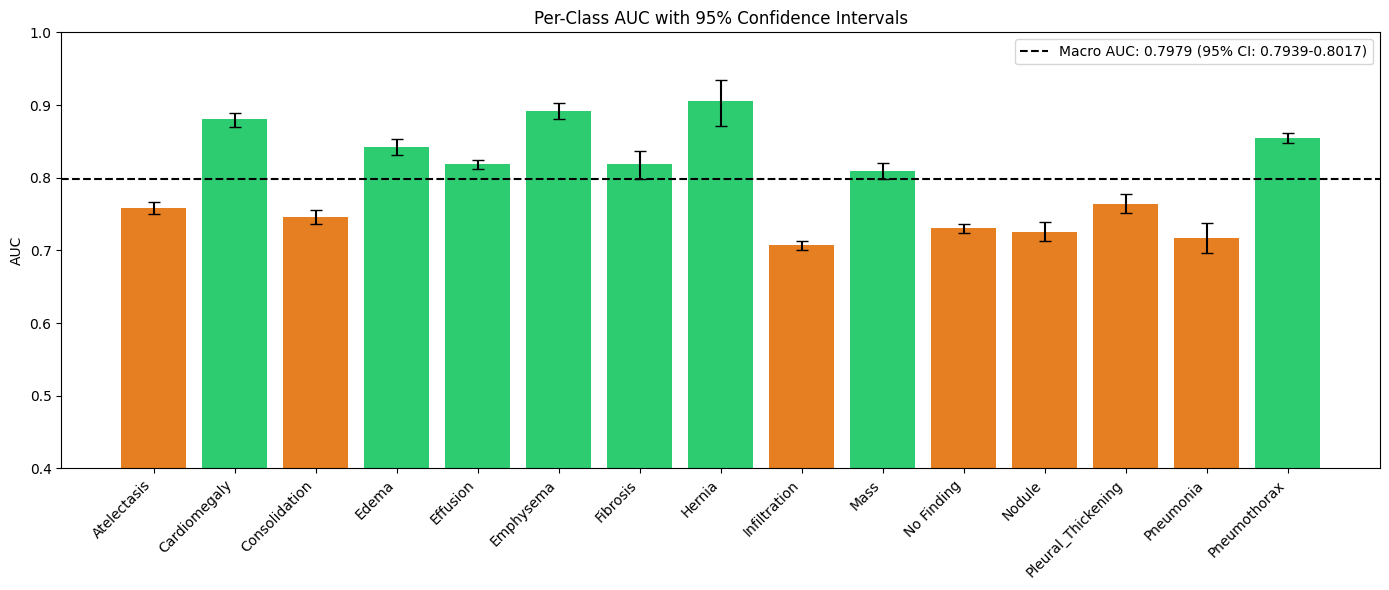

  Saved: per_class_auc.png


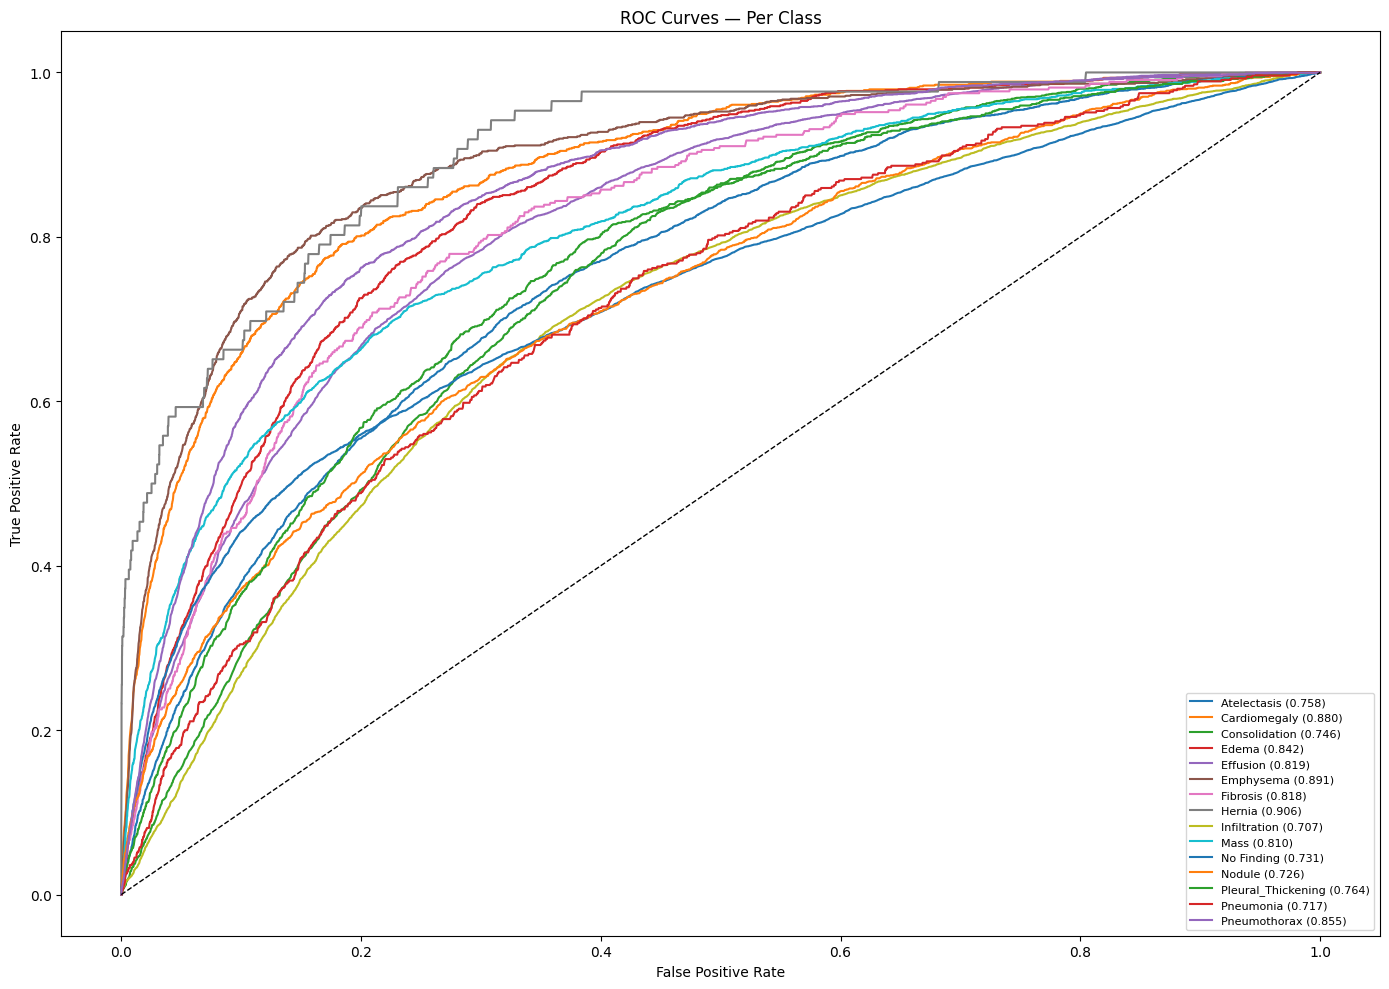

  Saved: roc_curves.png


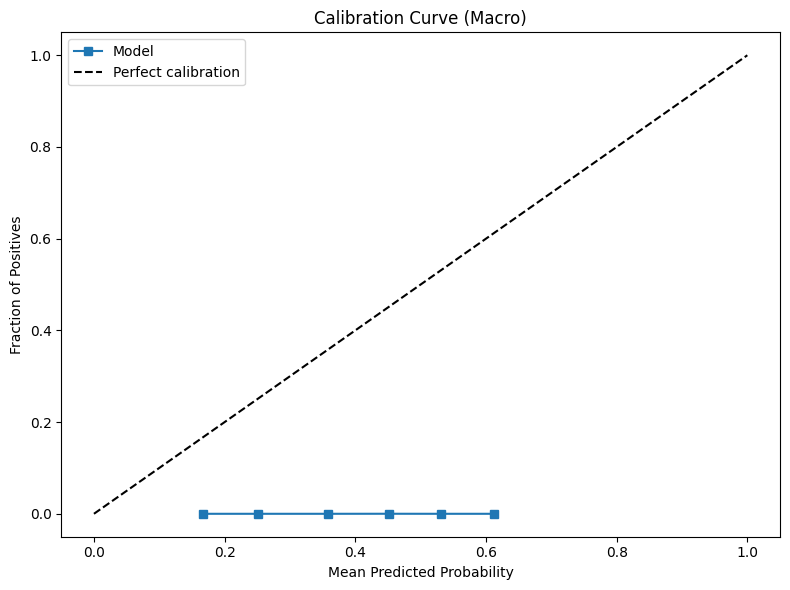

  Saved: calibration.png

PART 8 — Saving results to CSV...
  Saved: results.csv

  ALL EVALUATION COMPLETE
  Results saved to: /workspace/NIH/results

  Macro AUC : 0.7979 (95% CI: 0.7939 - 0.8017)
  Macro ECE : 0.3082
  Inference : 6.20 ms/image
  Params    : 86,758,599 (330.96 MB)


In [13]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, brier_score_loss)
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# ================================================================
#  COMPLETE EVALUATION BLOCK
#  Run this immediately after training finishes.
#  Requires: model, criterion, val_loader, test_loader,
#             disease_labels, NUM_CLASSES, device, all_t, all_o
#             (all_t and all_o from the test set in training script)
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_t = all_t.astype(np.float32)
all_o = all_o.astype(np.float32)
# ================================================================
# PART 1 — OPTIMAL THRESHOLDS FROM VALIDATION SET
# ================================================================
print("\n" + "="*60)
print("PART 1 — Finding optimal thresholds on validation set...")
print("="*60)

model.eval()
val_t, val_o = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        val_t.append(targets.cpu().numpy())
        val_o.append(torch.sigmoid(out).cpu().numpy())

val_t = np.vstack(val_t)
val_o = np.vstack(val_o)

val_t = val_t.astype(np.float32)
val_o = val_o.astype(np.float32)

thresholds = []
for i in range(NUM_CLASSES):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (val_o[:, i] >= t).astype(int)
        tp    = ((preds == 1) & (val_t[:, i] == 1)).sum()
        fp    = ((preds == 1) & (val_t[:, i] == 0)).sum()
        fn    = ((preds == 0) & (val_t[:, i] == 1)).sum()
        prec  = tp / (tp + fp + 1e-6)
        rec   = tp / (tp + fn + 1e-6)
        f1    = 2 * prec * rec / (prec + rec + 1e-6)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    thresholds.append(best_thresh)

print("\nOptimal thresholds per class:")
for label, t in zip(disease_labels, thresholds):
    print(f"  {label:<25} {t:.2f}")

# ================================================================
# PART 2 — PER-CLASS AUC WITH 95% CONFIDENCE INTERVALS
# ================================================================
print("\n" + "="*60)
print("PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...")
print("="*60)

N_BOOTSTRAP  = 1000
per_class_auc = roc_auc_score(all_t, all_o, average=None)
macro_auc     = roc_auc_score(all_t, all_o, average="macro")

# Bootstrap CI per class
ci_lower_list, ci_upper_list = [], []
macro_auc_boots = []

for _ in range(N_BOOTSTRAP):
    idx         = resample(np.arange(len(all_t)), random_state=None)
    boot_t      = all_t[idx]
    boot_o      = all_o[idx]
    # skip bootstrap sample if any class has only one label present
    if len(np.unique(boot_t)) < 2:
        continue
    try:
        boot_per_class = roc_auc_score(boot_t, boot_o, average=None)
        macro_auc_boots.append(roc_auc_score(boot_t, boot_o, average="macro"))
        ci_lower_list.append(boot_per_class)
        ci_upper_list.append(boot_per_class)
    except:
        continue

ci_lower_arr = np.percentile(ci_lower_list,  2.5, axis=0)
ci_upper_arr = np.percentile(ci_upper_list, 97.5, axis=0)
macro_ci_lo  = np.percentile(macro_auc_boots,  2.5)
macro_ci_hi  = np.percentile(macro_auc_boots, 97.5)

print(f"\n{'Class':<25} {'AUC':>6}  {'95% CI'}")
print("-"*55)
for i, label in enumerate(disease_labels):
    print(f"  {label:<23} {per_class_auc[i]:.4f}  ({ci_lower_arr[i]:.4f} - {ci_upper_arr[i]:.4f})")
print("-"*55)
print(f"  {'MACRO AVERAGE':<23} {macro_auc:.4f}  ({macro_ci_lo:.4f} - {macro_ci_hi:.4f})")

# ================================================================
# PART 3 — CLASSIFICATION REPORT
# ================================================================
print("\n" + "="*60)
print("PART 3 — Classification Report (optimal thresholds)...")
print("="*60)

test_preds = np.zeros(all_o.shape, dtype=np.float32)
for i in range(NUM_CLASSES):
    test_preds[:, i] = (all_o[:, i] >= thresholds[i]).astype(np.float32)

report = classification_report(all_t, test_preds,
                               target_names=disease_labels,
                               zero_division=0)
print(report)

# ================================================================
# PART 4 — CALIBRATION (ECE)
# ================================================================
print("\n" + "="*60)
print("PART 4 — Calibration (Expected Calibration Error)...")
print("="*60)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask       = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc    = y_true[mask].mean()
        bin_conf   = y_prob[mask].mean()
        ece       += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece_per_class = []
for i in range(NUM_CLASSES):
    ece = expected_calibration_error(all_t[:, i], all_o[:, i])
    ece_per_class.append(ece)
    print(f"  {disease_labels[i]:<25} ECE: {ece:.4f}")

print(f"\n  {'MACRO ECE':<25} ECE: {np.mean(ece_per_class):.4f}")

# ================================================================
# PART 5 — INFERENCE TIME
# ================================================================
print("\n" + "="*60)
print("PART 5 — Inference Time...")
print("="*60)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure
torch.cuda.synchronize()
start_inf = time.time()
N_RUNS    = 100
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy_input)
torch.cuda.synchronize()
elapsed_inf = (time.time() - start_inf) / N_RUNS * 1000  # ms

print(f"  Inference time per image : {elapsed_inf:.2f} ms")
print(f"  Throughput               : {1000/elapsed_inf:.1f} images/sec")

# ================================================================
# PART 6 — MODEL SIZE AND PARAMETERS
# ================================================================
print("\n" + "="*60)
print("PART 6 — Model Size & Parameters...")
print("="*60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (MB)      : {total_params * 4 / 1024**2:.2f}")

# ================================================================
# PART 7 — PLOTS
# ================================================================
print("\n" + "="*60)
print("PART 7 — Generating plots...")
print("="*60)

# --- 7a. Per-class AUC bar chart ---
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e67e22' if a >= 0.7 else '#e74c3c'
          for a in per_class_auc]
plt.bar(disease_labels, per_class_auc, color=colors,
        yerr=[per_class_auc - ci_lower_arr, ci_upper_arr - per_class_auc],
        capsize=4, error_kw={'linewidth': 1.5})
plt.axhline(y=macro_auc, color='black', linestyle='--',
            label=f'Macro AUC: {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f}-{macro_ci_hi:.4f})')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Per-Class AUC with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_auc.png'), dpi=150)
plt.show()
print("  Saved: per_class_auc.png")

# --- 7b. ROC curves ---
plt.figure(figsize=(14, 10))
for i, label in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(all_t[:, i], all_o[:, i])
    plt.plot(fpr, tpr, label=f"{label} ({per_class_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Class')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("  Saved: roc_curves.png")

# --- 7c. Calibration plot (macro) ---
plt.figure(figsize=(8, 6))
mean_prob = all_o.mean(axis=1)
mean_true = all_t.mean(axis=1)
fraction_pos, mean_pred = calibration_curve(
    (mean_true > 0.5).astype(int), mean_prob, n_bins=10)
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Macro)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()
print("  Saved: calibration.png")

# ================================================================
# PART 8 — SAVE ALL NUMBERS TO CSV FOR EASY REPORTING
# ================================================================
print("\n" + "="*60)
print("PART 8 — Saving results to CSV...")
print("="*60)

import pandas as pd

results_df = pd.DataFrame({
    'Class'         : disease_labels,
    'AUC'           : per_class_auc,
    'CI_Lower'      : ci_lower_arr,
    'CI_Upper'      : ci_upper_arr,
    'ECE'           : ece_per_class,
    'Threshold'     : thresholds
})

# Add macro row
macro_row = pd.DataFrame([{
    'Class'    : 'MACRO',
    'AUC'      : macro_auc,
    'CI_Lower' : macro_ci_lo,
    'CI_Upper' : macro_ci_hi,
    'ECE'      : np.mean(ece_per_class),
    'Threshold': '-'
}])

results_df = pd.concat([results_df, macro_row], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
print(f"  Saved: results.csv")

# Summary
print("\n" + "="*60)
print("  ALL EVALUATION COMPLETE")
print(f"  Results saved to: {RESULTS_DIR}")
print("="*60)
print(f"\n  Macro AUC : {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f} - {macro_ci_hi:.4f})")
print(f"  Macro ECE : {np.mean(ece_per_class):.4f}")
print(f"  Inference : {elapsed_inf:.2f} ms/image")
print(f"  Params    : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")


Model Saving

In [14]:
import os
import torch

# ================================================================
#  MODEL SAVE & PORTABILITY CHECK
#  Run after evaluation block.
#  Saves model in 2 formats + a CPU-compatible version for laptop.
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAME = "swin"   # change this per model you run

# ================================================================
# SAVE 1 — Full checkpoint (weights + optimizer + epoch info)
#           Use this if you want to resume training later
# ================================================================
full_ckpt_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_full_checkpoint.pth")
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : EPOCHS,
    'best_val_auc'        : best_val_auc,
    'num_classes'         : NUM_CLASSES,
    'disease_labels'      : disease_labels,
}, full_ckpt_path)
print(f"Full checkpoint saved : {full_ckpt_path}")
print(f"Size                  : {os.path.getsize(full_ckpt_path) / 1024**2:.2f} MB")

# ================================================================
# SAVE 2 — Weights only, mapped to CPU
#           Use this to load on your laptop without a GPU
# ================================================================
cpu_weights_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_cpu_weights.pth")
cpu_state_dict   = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save(cpu_state_dict, cpu_weights_path)
print(f"\nCPU weights saved     : {cpu_weights_path}")
print(f"Size                  : {os.path.getsize(cpu_weights_path) / 1024**2:.2f} MB")

# ================================================================
# PORTABILITY CHECK — Simulate loading on a CPU-only machine
#                     (exactly what your laptop will do)
# ================================================================
print("\n" + "="*60)
print("PORTABILITY CHECK — Simulating laptop load (CPU only)...")
print("="*60)

# Recreate model architecture on CPU
model_cpu  = SwinClassifier(NUM_CLASSES, pretrained=False)   # change class name per model
model_cpu.load_state_dict(
    torch.load(cpu_weights_path, map_location='cpu')
)
model_cpu.eval()

# Run one dummy forward pass on CPU
dummy    = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    output = model_cpu(dummy)

print(f"  Model loaded on CPU   : OK")
print(f"  Input shape           : {dummy.shape}")
print(f"  Output shape          : {output.shape}")
print(f"  Output (raw logits)   : {output.detach().numpy().round(4)}")
print(f"  Output (sigmoid)      : {torch.sigmoid(output).detach().numpy().round(4)}")
print("\n  Model is portable and runs correctly on CPU.")
print("  Safe to download and run on your laptop.")

# ================================================================
# PRINT DOWNLOAD INSTRUCTIONS
# ================================================================
print("\n" + "="*60)
print("  FILES TO DOWNLOAD FROM SERVER")
print("="*60)
print(f"\n  Folder to download : {RESULTS_DIR}")
print(f"\n  Contents:")
print(f"    {MODEL_NAME}_full_checkpoint.pth  — resume training / GPU inference")
print(f"    {MODEL_NAME}_cpu_weights.pth      — laptop inference (no GPU needed)")
print(f"    results.csv                        — all metrics")
print(f"    per_class_auc.png                  — AUC bar chart")
print(f"    roc_curves.png                     — ROC curves")
print(f"    calibration.png                    — calibration plot")
print(f"\n  To download from server to local machine, run this")
print(f"  in your LOCAL terminal (not inside Docker):")
print(f"\n    scp -r user@server_ip:{RESULTS_DIR} ~/Downloads/{MODEL_NAME}_results")
print("="*60)


Full checkpoint saved : /workspace/NIH/results/swin_full_checkpoint.pth
Size                  : 993.28 MB

CPU weights saved     : /workspace/NIH/results/swin_cpu_weights.pth
Size                  : 331.06 MB

PORTABILITY CHECK — Simulating laptop load (CPU only)...
  Model loaded on CPU   : OK
  Input shape           : torch.Size([1, 3, 224, 224])
  Output shape          : torch.Size([1, 15])
  Output (raw logits)   : [[-0.3162 -2.7093 -0.3647 -1.6475 -0.3131 -1.8387 -1.3848 -2.2488 -0.2713
  -1.4628  0.4056 -0.9053 -1.2224 -0.4878 -0.965 ]]
  Output (sigmoid)      : [[0.4216 0.0624 0.4098 0.1615 0.4224 0.1372 0.2002 0.0955 0.4326 0.188
  0.6    0.288  0.2275 0.3804 0.2759]]

  Model is portable and runs correctly on CPU.
  Safe to download and run on your laptop.

  FILES TO DOWNLOAD FROM SERVER

  Folder to download : /workspace/NIH/results

  Contents:
    swin_full_checkpoint.pth  — resume training / GPU inference
    swin_cpu_weights.pth      — laptop inference (no GPU needed)
  

Efficient Net V2

In [12]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import timm

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
# EfficientNetV2-M native resolution is 480x480 but 384x384
# is a good balance between accuracy and VRAM on 16GB
train_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

# 32 for 384x384 resolution to avoid OOM on 16GB VRAM
BATCH = 32

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)

val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== MODEL — EfficientNetV2-M =====================
class EfficientNetV2Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_m',
            pretrained=pretrained,
            num_classes=0,        # remove default head
            global_pool='avg'
        )
        in_features     = self.backbone.num_features   # 1280 for M variant
        self.dropout    = nn.Dropout(0.5)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== SETUP =====================
model     = EfficientNetV2Classifier(NUM_CLASSES, pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_efficientnetv2.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: EfficientNetV2-M (pretrained ImageNet)")
print(f"Total parameters : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}{current_lr:<12.6f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda

Model: EfficientNetV2-M (pretrained ImageNet)
Total parameters : 52,877,571 (201.71 MB)

Epoch   Train Loss    Val Loss 

Evaluation Block


PART 1 — Finding optimal thresholds on validation set...

Optimal thresholds per class:
  Atelectasis               0.65
  Cardiomegaly              0.85
  Consolidation             0.75
  Edema                     0.85
  Effusion                  0.80
  Emphysema                 0.85
  Fibrosis                  0.85
  Hernia                    0.85
  Infiltration              0.55
  Mass                      0.85
  No Finding                0.30
  Nodule                    0.80
  Pleural_Thickening        0.85
  Pneumonia                 0.80
  Pneumothorax              0.80

PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...

Class                        AUC  95% CI
-------------------------------------------------------
  Atelectasis             0.7705  (0.7624 - 0.7791)
  Cardiomegaly            0.8836  (0.8734 - 0.8937)
  Consolidation           0.7409  (0.7303 - 0.7504)
  Edema                   0.8394  (0.8284 - 0.8498)
  Effusion                0.8289  (0.8230 - 0.8

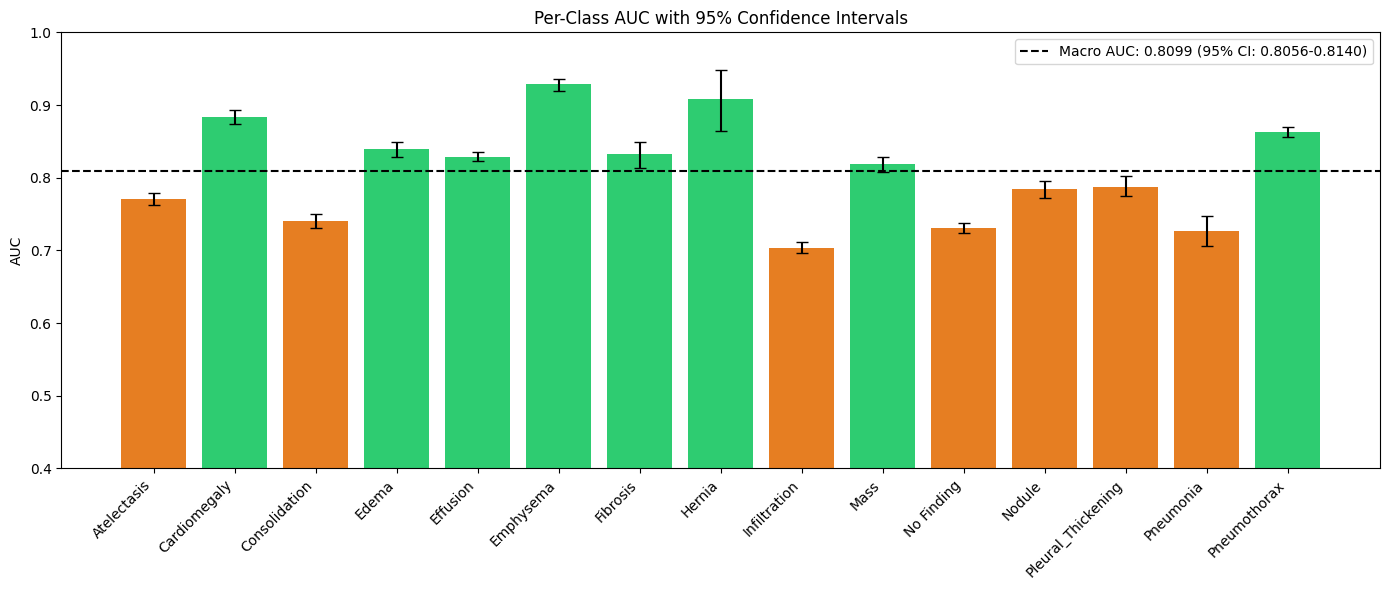

  Saved: per_class_auc.png


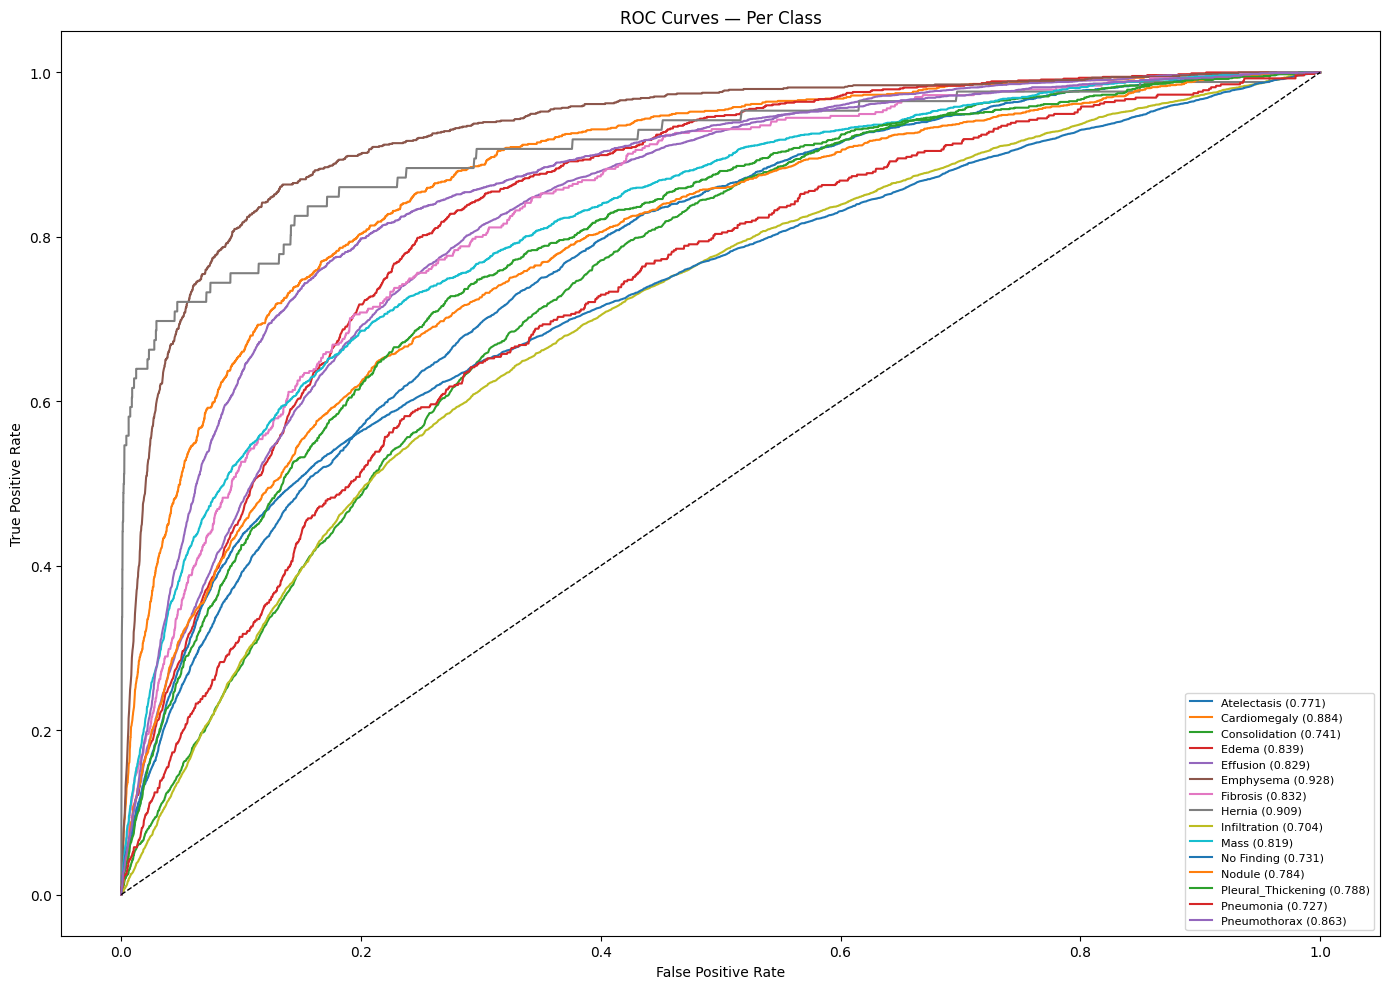

  Saved: roc_curves.png


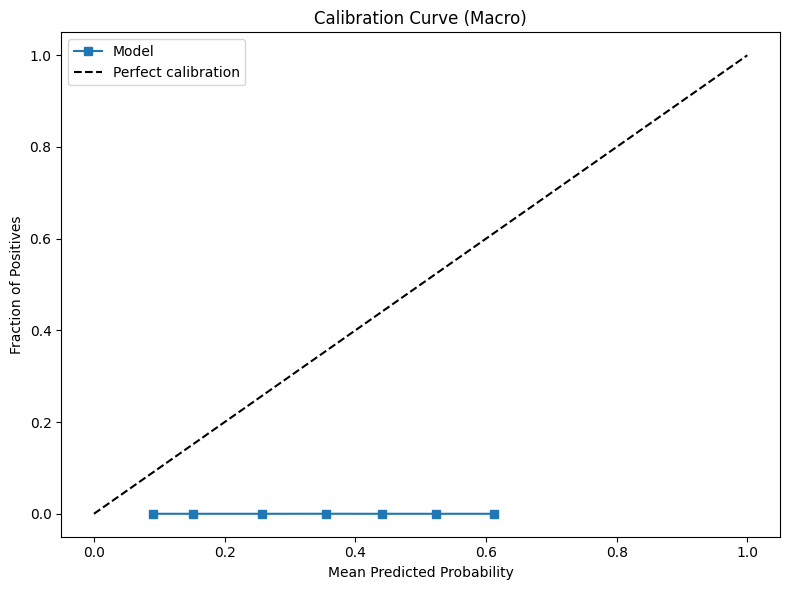

  Saved: calibration.png

PART 8 — Saving results to CSV...
  Saved: results.csv

  ALL EVALUATION COMPLETE
  Results saved to: /workspace/NIH/results

  Macro AUC : 0.8099 (95% CI: 0.8056 - 0.8140)
  Macro ECE : 0.2654
  Inference : 6.72 ms/image
  Params    : 52,877,571 (201.71 MB)


In [14]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, brier_score_loss)
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# ================================================================
#  COMPLETE EVALUATION BLOCK
#  Run this immediately after training finishes.
#  Requires: model, criterion, val_loader, test_loader,
#             disease_labels, NUM_CLASSES, device, all_t, all_o
#             (all_t and all_o from the test set in training script)
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_t = all_t.astype(np.float32)
all_o = all_o.astype(np.float32)
# ================================================================
# PART 1 — OPTIMAL THRESHOLDS FROM VALIDATION SET
# ================================================================
print("\n" + "="*60)
print("PART 1 — Finding optimal thresholds on validation set...")
print("="*60)

model.eval()
val_t, val_o = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        val_t.append(targets.cpu().numpy())
        val_o.append(torch.sigmoid(out).cpu().numpy())

val_t = np.vstack(val_t)
val_o = np.vstack(val_o)

val_t = val_t.astype(np.float32)
val_o = val_o.astype(np.float32)

thresholds = []
for i in range(NUM_CLASSES):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (val_o[:, i] >= t).astype(int)
        tp    = ((preds == 1) & (val_t[:, i] == 1)).sum()
        fp    = ((preds == 1) & (val_t[:, i] == 0)).sum()
        fn    = ((preds == 0) & (val_t[:, i] == 1)).sum()
        prec  = tp / (tp + fp + 1e-6)
        rec   = tp / (tp + fn + 1e-6)
        f1    = 2 * prec * rec / (prec + rec + 1e-6)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    thresholds.append(best_thresh)

print("\nOptimal thresholds per class:")
for label, t in zip(disease_labels, thresholds):
    print(f"  {label:<25} {t:.2f}")

# ================================================================
# PART 2 — PER-CLASS AUC WITH 95% CONFIDENCE INTERVALS
# ================================================================
print("\n" + "="*60)
print("PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...")
print("="*60)

N_BOOTSTRAP  = 1000
per_class_auc = roc_auc_score(all_t, all_o, average=None)
macro_auc     = roc_auc_score(all_t, all_o, average="macro")

# Bootstrap CI per class
ci_lower_list, ci_upper_list = [], []
macro_auc_boots = []

for _ in range(N_BOOTSTRAP):
    idx         = resample(np.arange(len(all_t)), random_state=None)
    boot_t      = all_t[idx]
    boot_o      = all_o[idx]
    # skip bootstrap sample if any class has only one label present
    if len(np.unique(boot_t)) < 2:
        continue
    try:
        boot_per_class = roc_auc_score(boot_t, boot_o, average=None)
        macro_auc_boots.append(roc_auc_score(boot_t, boot_o, average="macro"))
        ci_lower_list.append(boot_per_class)
        ci_upper_list.append(boot_per_class)
    except:
        continue

ci_lower_arr = np.percentile(ci_lower_list,  2.5, axis=0)
ci_upper_arr = np.percentile(ci_upper_list, 97.5, axis=0)
macro_ci_lo  = np.percentile(macro_auc_boots,  2.5)
macro_ci_hi  = np.percentile(macro_auc_boots, 97.5)

print(f"\n{'Class':<25} {'AUC':>6}  {'95% CI'}")
print("-"*55)
for i, label in enumerate(disease_labels):
    print(f"  {label:<23} {per_class_auc[i]:.4f}  ({ci_lower_arr[i]:.4f} - {ci_upper_arr[i]:.4f})")
print("-"*55)
print(f"  {'MACRO AVERAGE':<23} {macro_auc:.4f}  ({macro_ci_lo:.4f} - {macro_ci_hi:.4f})")

# ================================================================
# PART 3 — CLASSIFICATION REPORT
# ================================================================
print("\n" + "="*60)
print("PART 3 — Classification Report (optimal thresholds)...")
print("="*60)

test_preds = np.zeros(all_o.shape, dtype=np.float32)
for i in range(NUM_CLASSES):
    test_preds[:, i] = (all_o[:, i] >= thresholds[i]).astype(np.float32)

report = classification_report(all_t, test_preds,
                               target_names=disease_labels,
                               zero_division=0)
print(report)

# ================================================================
# PART 4 — CALIBRATION (ECE)
# ================================================================
print("\n" + "="*60)
print("PART 4 — Calibration (Expected Calibration Error)...")
print("="*60)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask       = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc    = y_true[mask].mean()
        bin_conf   = y_prob[mask].mean()
        ece       += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece_per_class = []
for i in range(NUM_CLASSES):
    ece = expected_calibration_error(all_t[:, i], all_o[:, i])
    ece_per_class.append(ece)
    print(f"  {disease_labels[i]:<25} ECE: {ece:.4f}")

print(f"\n  {'MACRO ECE':<25} ECE: {np.mean(ece_per_class):.4f}")

# ================================================================
# PART 5 — INFERENCE TIME
# ================================================================
print("\n" + "="*60)
print("PART 5 — Inference Time...")
print("="*60)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure
torch.cuda.synchronize()
start_inf = time.time()
N_RUNS    = 100
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy_input)
torch.cuda.synchronize()
elapsed_inf = (time.time() - start_inf) / N_RUNS * 1000  # ms

print(f"  Inference time per image : {elapsed_inf:.2f} ms")
print(f"  Throughput               : {1000/elapsed_inf:.1f} images/sec")

# ================================================================
# PART 6 — MODEL SIZE AND PARAMETERS
# ================================================================
print("\n" + "="*60)
print("PART 6 — Model Size & Parameters...")
print("="*60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (MB)      : {total_params * 4 / 1024**2:.2f}")

# ================================================================
# PART 7 — PLOTS
# ================================================================
print("\n" + "="*60)
print("PART 7 — Generating plots...")
print("="*60)

# --- 7a. Per-class AUC bar chart ---
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e67e22' if a >= 0.7 else '#e74c3c'
          for a in per_class_auc]
plt.bar(disease_labels, per_class_auc, color=colors,
        yerr=[per_class_auc - ci_lower_arr, ci_upper_arr - per_class_auc],
        capsize=4, error_kw={'linewidth': 1.5})
plt.axhline(y=macro_auc, color='black', linestyle='--',
            label=f'Macro AUC: {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f}-{macro_ci_hi:.4f})')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Per-Class AUC with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_auc.png'), dpi=150)
plt.show()
print("  Saved: per_class_auc.png")

# --- 7b. ROC curves ---
plt.figure(figsize=(14, 10))
for i, label in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(all_t[:, i], all_o[:, i])
    plt.plot(fpr, tpr, label=f"{label} ({per_class_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Class')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("  Saved: roc_curves.png")

# --- 7c. Calibration plot (macro) ---
plt.figure(figsize=(8, 6))
mean_prob = all_o.mean(axis=1)
mean_true = all_t.mean(axis=1)
fraction_pos, mean_pred = calibration_curve(
    (mean_true > 0.5).astype(int), mean_prob, n_bins=10)
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Macro)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()
print("  Saved: calibration.png")

# ================================================================
# PART 8 — SAVE ALL NUMBERS TO CSV FOR EASY REPORTING
# ================================================================
print("\n" + "="*60)
print("PART 8 — Saving results to CSV...")
print("="*60)

import pandas as pd

results_df = pd.DataFrame({
    'Class'         : disease_labels,
    'AUC'           : per_class_auc,
    'CI_Lower'      : ci_lower_arr,
    'CI_Upper'      : ci_upper_arr,
    'ECE'           : ece_per_class,
    'Threshold'     : thresholds
})

# Add macro row
macro_row = pd.DataFrame([{
    'Class'    : 'MACRO',
    'AUC'      : macro_auc,
    'CI_Lower' : macro_ci_lo,
    'CI_Upper' : macro_ci_hi,
    'ECE'      : np.mean(ece_per_class),
    'Threshold': '-'
}])

results_df = pd.concat([results_df, macro_row], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
print(f"  Saved: results.csv")

# Summary
print("\n" + "="*60)
print("  ALL EVALUATION COMPLETE")
print(f"  Results saved to: {RESULTS_DIR}")
print("="*60)
print(f"\n  Macro AUC : {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f} - {macro_ci_hi:.4f})")
print(f"  Macro ECE : {np.mean(ece_per_class):.4f}")
print(f"  Inference : {elapsed_inf:.2f} ms/image")
print(f"  Params    : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")


Model Saving

In [15]:
import os
import torch

# ================================================================
#  MODEL SAVE & PORTABILITY CHECK
#  Run after evaluation block.
#  Saves model in 2 formats + a CPU-compatible version for laptop.
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAME = "efficientnetv2"   # change this per model you run

# ================================================================
# SAVE 1 — Full checkpoint (weights + optimizer + epoch info)
#           Use this if you want to resume training later
# ================================================================
full_ckpt_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_full_checkpoint.pth")
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : EPOCHS,
    'best_val_auc'        : best_val_auc,
    'num_classes'         : NUM_CLASSES,
    'disease_labels'      : disease_labels,
}, full_ckpt_path)
print(f"Full checkpoint saved : {full_ckpt_path}")
print(f"Size                  : {os.path.getsize(full_ckpt_path) / 1024**2:.2f} MB")

# ================================================================
# SAVE 2 — Weights only, mapped to CPU
#           Use this to load on your laptop without a GPU
# ================================================================
cpu_weights_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_cpu_weights.pth")
cpu_state_dict   = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save(cpu_state_dict, cpu_weights_path)
print(f"\nCPU weights saved     : {cpu_weights_path}")
print(f"Size                  : {os.path.getsize(cpu_weights_path) / 1024**2:.2f} MB")

# ================================================================
# PORTABILITY CHECK — Simulate loading on a CPU-only machine
#                     (exactly what your laptop will do)
# ================================================================
print("\n" + "="*60)
print("PORTABILITY CHECK — Simulating laptop load (CPU only)...")
print("="*60)

# Recreate model architecture on CPU
model_cpu  = EfficientNetV2Classifier(NUM_CLASSES, pretrained=False)   # change class name per model
model_cpu.load_state_dict(
    torch.load(cpu_weights_path, map_location='cpu')
)
model_cpu.eval()

# Run one dummy forward pass on CPU
dummy    = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    output = model_cpu(dummy)

print(f"  Model loaded on CPU   : OK")
print(f"  Input shape           : {dummy.shape}")
print(f"  Output shape          : {output.shape}")
print(f"  Output (raw logits)   : {output.detach().numpy().round(4)}")
print(f"  Output (sigmoid)      : {torch.sigmoid(output).detach().numpy().round(4)}")
print("\n  Model is portable and runs correctly on CPU.")
print("  Safe to download and run on your laptop.")

# ================================================================
# PRINT DOWNLOAD INSTRUCTIONS
# ================================================================
print("\n" + "="*60)
print("  FILES TO DOWNLOAD FROM SERVER")
print("="*60)
print(f"\n  Folder to download : {RESULTS_DIR}")
print(f"\n  Contents:")
print(f"    {MODEL_NAME}_full_checkpoint.pth  — resume training / GPU inference")
print(f"    {MODEL_NAME}_cpu_weights.pth      — laptop inference (no GPU needed)")
print(f"    results.csv                        — all metrics")
print(f"    per_class_auc.png                  — AUC bar chart")
print(f"    roc_curves.png                     — ROC curves")
print(f"    calibration.png                    — calibration plot")
print(f"\n  To download from server to local machine, run this")
print(f"  in your LOCAL terminal (not inside Docker):")
print(f"\n    scp -r user@server_ip:{RESULTS_DIR} ~/Downloads/{MODEL_NAME}_results")
print("="*60)


Full checkpoint saved : /workspace/NIH/results/efficientnetv2_full_checkpoint.pth
Size                  : 607.24 MB

CPU weights saved     : /workspace/NIH/results/efficientnetv2_cpu_weights.pth
Size                  : 203.18 MB

PORTABILITY CHECK — Simulating laptop load (CPU only)...
  Model loaded on CPU   : OK
  Input shape           : torch.Size([1, 3, 224, 224])
  Output shape          : torch.Size([1, 15])
  Output (raw logits)   : [[ 0.4236 -1.0593  0.5041  0.4264 -0.0419 -2.0502 -2.4751 -1.363   0.4124
  -0.4455  0.126  -1.1177 -0.8275 -0.119  -0.8447]]
  Output (sigmoid)      : [[0.6043 0.2574 0.6234 0.605  0.4895 0.114  0.0776 0.2038 0.6017 0.3904
  0.5315 0.2464 0.3042 0.4703 0.3005]]

  Model is portable and runs correctly on CPU.
  Safe to download and run on your laptop.

  FILES TO DOWNLOAD FROM SERVER

  Folder to download : /workspace/NIH/results

  Contents:
    efficientnetv2_full_checkpoint.pth  — resume training / GPU inference
    efficientnetv2_cpu_weights.pth  

ConvNext V2 Base

In [11]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import timm

# ===================== PATHS =====================
DATA_DIR       = "/workspace/NIH"
CSV_PATH       = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMG_DIR        = os.path.join(DATA_DIR, "images")
TRAIN_VAL_LIST = os.path.join(DATA_DIR, "train_val_list.txt")
TEST_LIST      = os.path.join(DATA_DIR, "test_list.txt")

# ===================== LOAD CSV =====================
df = pd.read_csv(CSV_PATH)
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

disease_labels = sorted(set(
    label
    for sub in df['Finding Labels'].str.split('|')
    for label in sub
))

df = pd.concat([
    df,
    df['Finding Labels'].str.get_dummies(sep='|')
], axis=1)

NUM_CLASSES = len(disease_labels)
print(f"Total samples : {len(df)}")
print(f"NUM_CLASSES   : {NUM_CLASSES}")
print(f"Labels        : {disease_labels}")

# ===================== OFFICIAL PATIENT-LEVEL TRAIN+VAL / TEST SPLIT =====================
with open(TRAIN_VAL_LIST) as f:
    train_val_images = set(f.read().splitlines())

with open(TEST_LIST) as f:
    test_images = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_images)].reset_index(drop=True)
test_df      = df[df['Image Index'].isin(test_images)].reset_index(drop=True)

print(f"\nTrain+Val images : {len(train_val_df)}")
print(f"Test images      : {len(test_df)}")

# ===================== LEAKAGE CHECK: TRAIN+VAL vs TEST =====================
train_val_patients = set(train_val_df['Patient ID'].unique())
test_patients      = set(test_df['Patient ID'].unique())
overlap            = train_val_patients & test_patients
print(f"\nUnique patients in Train+Val : {len(train_val_patients)}")
print(f"Unique patients in Test      : {len(test_patients)}")
print(f"Patient overlap (leakage check): {len(overlap)}  <- must be 0")

# ===================== PATIENT-LEVEL MULTILABEL STRATIFIED TRAIN / VAL SPLIT =====================
patient_labels = (
    train_val_df.groupby('Patient ID')[disease_labels]
    .max()
    .reset_index()
)

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_pat_idx, val_pat_idx = next(msss.split(
    np.zeros(len(patient_labels)),
    patient_labels[disease_labels].values
))

train_patients = patient_labels.iloc[train_pat_idx]['Patient ID']
val_patients   = patient_labels.iloc[val_pat_idx]['Patient ID']

train_df = train_val_df[train_val_df['Patient ID'].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df['Patient ID'].isin(val_patients)].reset_index(drop=True)

print(f"\nFinal split:")
print(f"  Train : {len(train_patients):>5} patients | {len(train_df):>6} images")
print(f"  Val   : {len(val_patients):>5} patients | {len(val_df):>6} images")
print(f"  Test  : {test_df['Patient ID'].nunique():>5} patients | {len(test_df):>6} images")

# ===================== FULL LEAKAGE CHECK ACROSS ALL 3 SPLITS =====================
train_pts = set(train_df['Patient ID'].unique())
val_pts   = set(val_df['Patient ID'].unique())
test_pts  = set(test_df['Patient ID'].unique())
print(f"\nLeakage checks (all must be 0):")
print(f"  Train ∩ Val  : {len(train_pts & val_pts)}")
print(f"  Train ∩ Test : {len(train_pts & test_pts)}")
print(f"  Val   ∩ Test : {len(val_pts & test_pts)}")

# ===================== CLASS WEIGHTS =====================
freq_pos    = train_df[disease_labels].values.mean(axis=0)
freq_neg    = 1 - freq_pos
pos_weights = torch.tensor(freq_neg / (freq_pos + 1e-6), dtype=torch.float32)
print("\nClass weights (top 5 rarest):")
for label, w in sorted(zip(disease_labels, pos_weights.numpy()), key=lambda x: -x[1])[:5]:
    print(f"  {label:<25} {w:.2f}")

# ===================== TRANSFORMS =====================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== DATASET =====================
class NIH(Dataset):
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.y         = df[disease_labels].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r        = self.df.iloc[i]
        img_path = os.path.join(IMG_DIR, r["Image Index"])
        img      = Image.open(img_path).convert("RGB")
        img      = self.transform(img)
        return img, torch.tensor(self.y[i])

BATCH = 32   # 32 for ConvNeXtV2 Base to avoid OOM on 16GB VRAM

train_loader = DataLoader(NIH(train_df, train_transform),
                          batch_size=BATCH, shuffle=True,
                          num_workers=12, pin_memory=True)

val_loader   = DataLoader(NIH(val_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

test_loader  = DataLoader(NIH(test_df, val_transform),
                          batch_size=BATCH, shuffle=False,
                          num_workers=12, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice:", device)

# ===================== MODEL — ConvNeXtV2 Base =====================
class ConvNeXtV2Classifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'convnextv2_base',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        in_features     = self.backbone.num_features   # 1024 for base
        self.dropout    = nn.Dropout(0.5)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# ===================== BCE LOSS WITH CLASS WEIGHTS =====================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(device))

# ===================== SETUP =====================
model     = ConvNeXtV2Classifier(NUM_CLASSES, pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS    = 20
WARMUP    = 3
SAVE_PATH = "/workspace/NIH/best_convnextv2.pth"

warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP, eta_min=1e-6)
scheduler    = SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP])
scaler       = torch.amp.GradScaler('cuda')

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: ConvNeXtV2-Base (pretrained ImageNet)")
print(f"Total parameters : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")

# ===================== TRAINING =====================
best_val_auc = 0.0
best_epoch   = 0

print("\n" + "="*80)
print(f"{'Epoch':<8}{'Train Loss':<14}{'Val Loss':<12}{'Val AUC':<12}{'LR':<12}{'Time'}")
print("="*80)

for epoch in range(EPOCHS):

    start = time.time()

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for imgs, targets in train_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss     = 0.0
    all_t, all_o = [], []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, targets)
            val_loss += loss.item()
            all_t.append(targets.cpu().numpy())
            all_o.append(torch.sigmoid(out).cpu().numpy())

    val_loss /= len(val_loader)
    val_auc   = roc_auc_score(np.vstack(all_t), np.vstack(all_o), average="macro")

    # ---------- SAVE BEST ----------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), SAVE_PATH)
        saved_marker = " <-- best saved"
    else:
        saved_marker = ""

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    elapsed = int(time.time() - start)

    print(f"{epoch+1:<8}{train_loss:<14.4f}{val_loss:<12.4f}{val_auc:<12.4f}{current_lr:<12.6f}{elapsed}s{saved_marker}")

print("="*80)
print(f"\nBest Val AUC : {best_val_auc:.4f} at Epoch {best_epoch}")

# ===================== FINAL TEST (best model) =====================
print("\nLoading best model for final test evaluation...")
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

test_loss    = 0.0
all_t, all_o = [], []

with torch.no_grad():
    for imgs, targets in test_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, targets)
        test_loss += loss.item()
        all_t.append(targets.cpu().numpy())
        all_o.append(torch.sigmoid(out).cpu().numpy())

test_loss /= len(test_loader)
all_t      = np.vstack(all_t)
all_o      = np.vstack(all_o)
test_auc   = roc_auc_score(all_t, all_o, average="macro")

print("\n" + "="*45)
print("        FINAL TEST PERFORMANCE")
print("="*45)
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Test Macro AUC : {test_auc:.4f}")
print("="*45)

per_class_auc = roc_auc_score(all_t, all_o, average=None)
print("\nPer-class AUC:")
for label, auc in sorted(zip(disease_labels, per_class_auc), key=lambda x: -x[1]):
    print(f"  {label:<25} {auc:.4f}")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples : 112120
NUM_CLASSES   : 15
Labels        : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Train+Val images : 86524
Test images      : 25596

Unique patients in Train+Val : 28008
Unique patients in Test      : 2797
Patient overlap (leakage check): 0  <- must be 0

Final split:
  Train : 23761 patients |  73514 images
  Val   :  4247 patients |  13010 images
  Test  :  2797 patients |  25596 images

Leakage checks (all must be 0):
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

Class weights (top 5 rarest):
  Hernia                    601.21
  Pneumonia                 97.40
  Fibrosis                  69.68
  Edema                     62.32
  Emphysema                 59.75

Device: cuda



Model: ConvNeXtV2-Base (pretrained ImageNet)
Total parameters : 87,708,175 (334.58 MB)

Epoch   Train Loss    Val Loss    Val AUC     LR          Time
1       1.1525        1.0661      0.7629      0.000010    454s <-- best saved
2       1.1125        1.0493      0.7664      0.000040    449s <-- best saved
3       1.0297        0.9658      0.8039      0.000070    448s <-- best saved
4       1.0013        0.9909      0.7974      0.000100    448s
5       0.9546        0.9424      0.8110      0.000099    448s <-- best saved
6       0.9268        0.9420      0.8101      0.000097    447s
7       0.8791        0.9541      0.8062      0.000093    448s
8       0.8532        0.9589      0.8124      0.000087    449s <-- best saved
9       0.8073        0.9320      0.8209      0.000080    449s <-- best saved
10      0.7704        0.9464      0.8172      0.000073    447s
11      0.7092        1.0079      0.8240      0.000064    449s <-- best saved
12      0.6456        1.1214      0.8203      0.00

Evaluation Block


PART 1 — Finding optimal thresholds on validation set...

Optimal thresholds per class:
  Atelectasis               0.65
  Cardiomegaly              0.85
  Consolidation             0.85
  Edema                     0.85
  Effusion                  0.80
  Emphysema                 0.85
  Fibrosis                  0.85
  Hernia                    0.85
  Infiltration              0.55
  Mass                      0.85
  No Finding                0.30
  Nodule                    0.70
  Pleural_Thickening        0.80
  Pneumonia                 0.85
  Pneumothorax              0.85

PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...

Class                        AUC  95% CI
-------------------------------------------------------
  Atelectasis             0.7684  (0.7605 - 0.7763)
  Cardiomegaly            0.8944  (0.8851 - 0.9041)
  Consolidation           0.7501  (0.7396 - 0.7606)
  Edema                   0.8410  (0.8294 - 0.8519)
  Effusion                0.8215  (0.8153 - 0.8

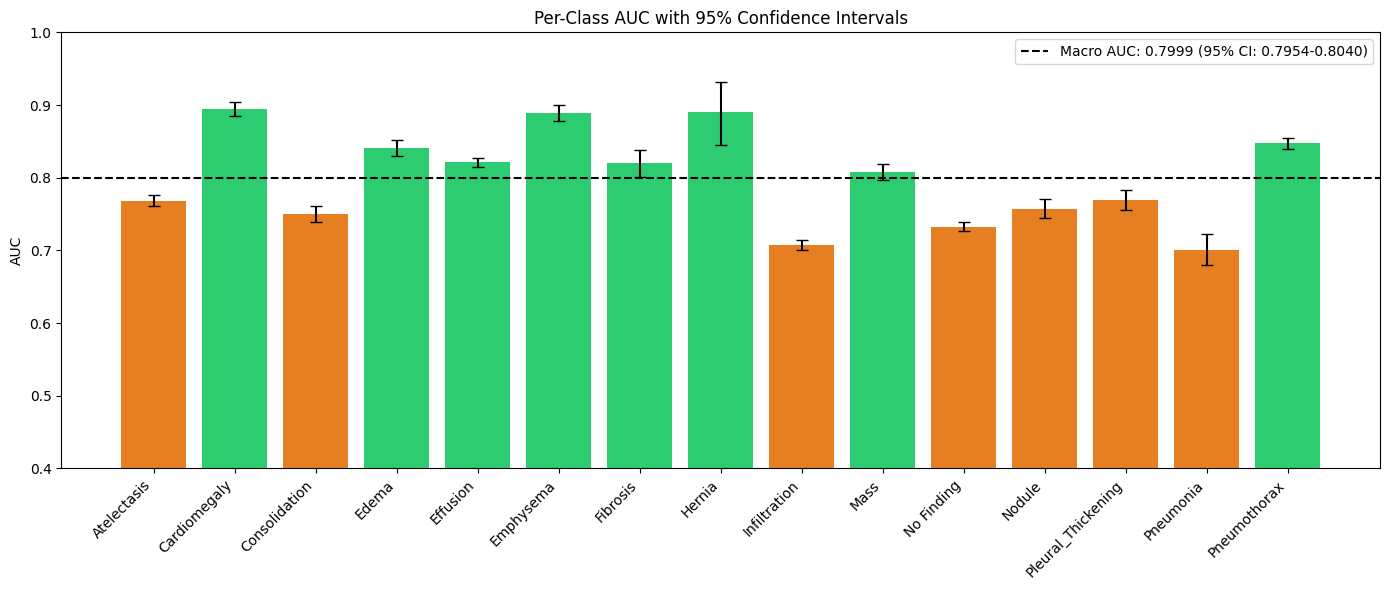

  Saved: per_class_auc.png


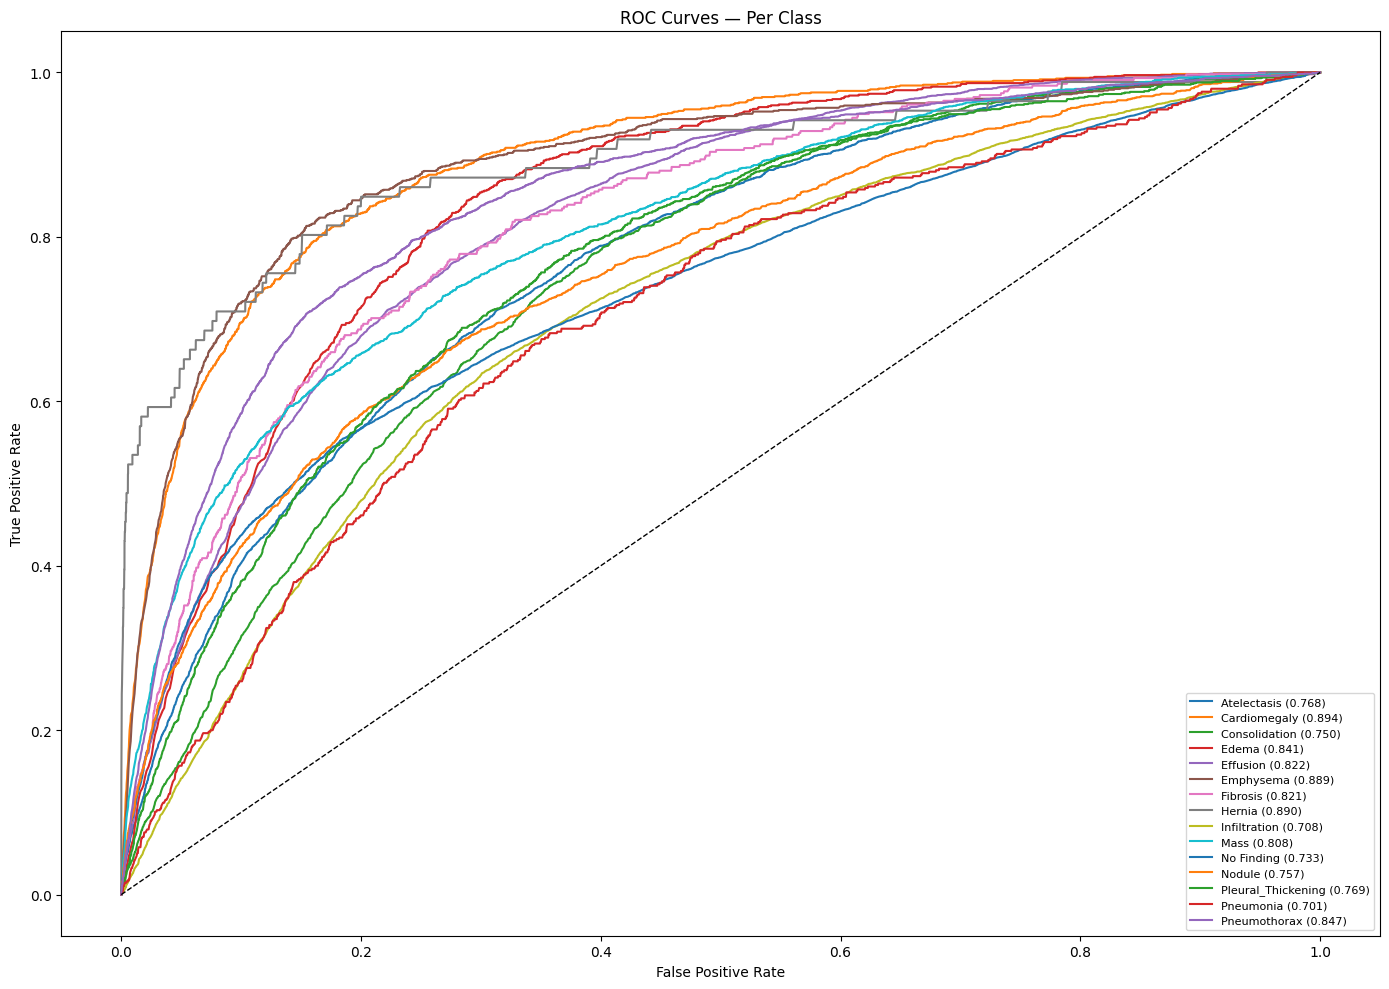

  Saved: roc_curves.png


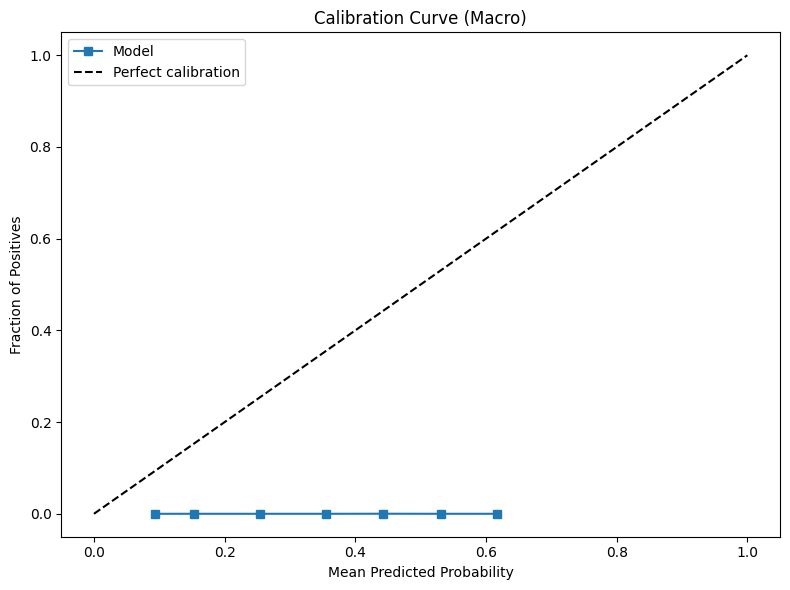

  Saved: calibration.png

PART 8 — Saving results to CSV...
  Saved: results.csv

  ALL EVALUATION COMPLETE
  Results saved to: /workspace/NIH/results

  Macro AUC : 0.7999 (95% CI: 0.7954 - 0.8040)
  Macro ECE : 0.2623
  Inference : 5.14 ms/image
  Params    : 87,708,175 (334.58 MB)


In [13]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, brier_score_loss)
from sklearn.utils import resample
from sklearn.calibration import calibration_curve

# ================================================================
#  COMPLETE EVALUATION BLOCK
#  Run this immediately after training finishes.
#  Requires: model, criterion, val_loader, test_loader,
#             disease_labels, NUM_CLASSES, device, all_t, all_o
#             (all_t and all_o from the test set in training script)
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

all_t = all_t.astype(np.float32)
all_o = all_o.astype(np.float32)
# ================================================================
# PART 1 — OPTIMAL THRESHOLDS FROM VALIDATION SET
# ================================================================
print("\n" + "="*60)
print("PART 1 — Finding optimal thresholds on validation set...")
print("="*60)

model.eval()
val_t, val_o = [], []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        val_t.append(targets.cpu().numpy())
        val_o.append(torch.sigmoid(out).cpu().numpy())

val_t = np.vstack(val_t)
val_o = np.vstack(val_o)

val_t = val_t.astype(np.float32)
val_o = val_o.astype(np.float32)

thresholds = []
for i in range(NUM_CLASSES):
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.9, 0.05):
        preds = (val_o[:, i] >= t).astype(int)
        tp    = ((preds == 1) & (val_t[:, i] == 1)).sum()
        fp    = ((preds == 1) & (val_t[:, i] == 0)).sum()
        fn    = ((preds == 0) & (val_t[:, i] == 1)).sum()
        prec  = tp / (tp + fp + 1e-6)
        rec   = tp / (tp + fn + 1e-6)
        f1    = 2 * prec * rec / (prec + rec + 1e-6)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    thresholds.append(best_thresh)

print("\nOptimal thresholds per class:")
for label, t in zip(disease_labels, thresholds):
    print(f"  {label:<25} {t:.2f}")

# ================================================================
# PART 2 — PER-CLASS AUC WITH 95% CONFIDENCE INTERVALS
# ================================================================
print("\n" + "="*60)
print("PART 2 — AUC + 95% Confidence Intervals (bootstrap n=1000)...")
print("="*60)

N_BOOTSTRAP  = 1000
per_class_auc = roc_auc_score(all_t, all_o, average=None)
macro_auc     = roc_auc_score(all_t, all_o, average="macro")

# Bootstrap CI per class
ci_lower_list, ci_upper_list = [], []
macro_auc_boots = []

for _ in range(N_BOOTSTRAP):
    idx         = resample(np.arange(len(all_t)), random_state=None)
    boot_t      = all_t[idx]
    boot_o      = all_o[idx]
    # skip bootstrap sample if any class has only one label present
    if len(np.unique(boot_t)) < 2:
        continue
    try:
        boot_per_class = roc_auc_score(boot_t, boot_o, average=None)
        macro_auc_boots.append(roc_auc_score(boot_t, boot_o, average="macro"))
        ci_lower_list.append(boot_per_class)
        ci_upper_list.append(boot_per_class)
    except:
        continue

ci_lower_arr = np.percentile(ci_lower_list,  2.5, axis=0)
ci_upper_arr = np.percentile(ci_upper_list, 97.5, axis=0)
macro_ci_lo  = np.percentile(macro_auc_boots,  2.5)
macro_ci_hi  = np.percentile(macro_auc_boots, 97.5)

print(f"\n{'Class':<25} {'AUC':>6}  {'95% CI'}")
print("-"*55)
for i, label in enumerate(disease_labels):
    print(f"  {label:<23} {per_class_auc[i]:.4f}  ({ci_lower_arr[i]:.4f} - {ci_upper_arr[i]:.4f})")
print("-"*55)
print(f"  {'MACRO AVERAGE':<23} {macro_auc:.4f}  ({macro_ci_lo:.4f} - {macro_ci_hi:.4f})")

# ================================================================
# PART 3 — CLASSIFICATION REPORT
# ================================================================
print("\n" + "="*60)
print("PART 3 — Classification Report (optimal thresholds)...")
print("="*60)

test_preds = np.zeros(all_o.shape, dtype=np.float32)
for i in range(NUM_CLASSES):
    test_preds[:, i] = (all_o[:, i] >= thresholds[i]).astype(np.float32)

report = classification_report(all_t, test_preds,
                               target_names=disease_labels,
                               zero_division=0)
print(report)

# ================================================================
# PART 4 — CALIBRATION (ECE)
# ================================================================
print("\n" + "="*60)
print("PART 4 — Calibration (Expected Calibration Error)...")
print("="*60)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask       = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i+1])
        if mask.sum() == 0:
            continue
        bin_acc    = y_true[mask].mean()
        bin_conf   = y_prob[mask].mean()
        ece       += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece_per_class = []
for i in range(NUM_CLASSES):
    ece = expected_calibration_error(all_t[:, i], all_o[:, i])
    ece_per_class.append(ece)
    print(f"  {disease_labels[i]:<25} ECE: {ece:.4f}")

print(f"\n  {'MACRO ECE':<25} ECE: {np.mean(ece_per_class):.4f}")

# ================================================================
# PART 5 — INFERENCE TIME
# ================================================================
print("\n" + "="*60)
print("PART 5 — Inference Time...")
print("="*60)

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Measure
torch.cuda.synchronize()
start_inf = time.time()
N_RUNS    = 100
with torch.no_grad():
    for _ in range(N_RUNS):
        _ = model(dummy_input)
torch.cuda.synchronize()
elapsed_inf = (time.time() - start_inf) / N_RUNS * 1000  # ms

print(f"  Inference time per image : {elapsed_inf:.2f} ms")
print(f"  Throughput               : {1000/elapsed_inf:.1f} images/sec")

# ================================================================
# PART 6 — MODEL SIZE AND PARAMETERS
# ================================================================
print("\n" + "="*60)
print("PART 6 — Model Size & Parameters...")
print("="*60)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Model size (MB)      : {total_params * 4 / 1024**2:.2f}")

# ================================================================
# PART 7 — PLOTS
# ================================================================
print("\n" + "="*60)
print("PART 7 — Generating plots...")
print("="*60)

# --- 7a. Per-class AUC bar chart ---
plt.figure(figsize=(14, 6))
colors = ['#2ecc71' if a >= 0.8 else '#e67e22' if a >= 0.7 else '#e74c3c'
          for a in per_class_auc]
plt.bar(disease_labels, per_class_auc, color=colors,
        yerr=[per_class_auc - ci_lower_arr, ci_upper_arr - per_class_auc],
        capsize=4, error_kw={'linewidth': 1.5})
plt.axhline(y=macro_auc, color='black', linestyle='--',
            label=f'Macro AUC: {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f}-{macro_ci_hi:.4f})')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.4, 1.0)
plt.ylabel('AUC')
plt.title('Per-Class AUC with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'per_class_auc.png'), dpi=150)
plt.show()
print("  Saved: per_class_auc.png")

# --- 7b. ROC curves ---
plt.figure(figsize=(14, 10))
for i, label in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(all_t[:, i], all_o[:, i])
    plt.plot(fpr, tpr, label=f"{label} ({per_class_auc[i]:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Per Class')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()
print("  Saved: roc_curves.png")

# --- 7c. Calibration plot (macro) ---
plt.figure(figsize=(8, 6))
mean_prob = all_o.mean(axis=1)
mean_true = all_t.mean(axis=1)
fraction_pos, mean_pred = calibration_curve(
    (mean_true > 0.5).astype(int), mean_prob, n_bins=10)
plt.plot(mean_pred, fraction_pos, 's-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Macro)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()
print("  Saved: calibration.png")

# ================================================================
# PART 8 — SAVE ALL NUMBERS TO CSV FOR EASY REPORTING
# ================================================================
print("\n" + "="*60)
print("PART 8 — Saving results to CSV...")
print("="*60)

import pandas as pd

results_df = pd.DataFrame({
    'Class'         : disease_labels,
    'AUC'           : per_class_auc,
    'CI_Lower'      : ci_lower_arr,
    'CI_Upper'      : ci_upper_arr,
    'ECE'           : ece_per_class,
    'Threshold'     : thresholds
})

# Add macro row
macro_row = pd.DataFrame([{
    'Class'    : 'MACRO',
    'AUC'      : macro_auc,
    'CI_Lower' : macro_ci_lo,
    'CI_Upper' : macro_ci_hi,
    'ECE'      : np.mean(ece_per_class),
    'Threshold': '-'
}])

results_df = pd.concat([results_df, macro_row], ignore_index=True)
results_df.to_csv(os.path.join(RESULTS_DIR, 'results.csv'), index=False)
print(f"  Saved: results.csv")

# Summary
print("\n" + "="*60)
print("  ALL EVALUATION COMPLETE")
print(f"  Results saved to: {RESULTS_DIR}")
print("="*60)
print(f"\n  Macro AUC : {macro_auc:.4f} (95% CI: {macro_ci_lo:.4f} - {macro_ci_hi:.4f})")
print(f"  Macro ECE : {np.mean(ece_per_class):.4f}")
print(f"  Inference : {elapsed_inf:.2f} ms/image")
print(f"  Params    : {total_params:,} ({total_params * 4 / 1024**2:.2f} MB)")


Model Saving

In [14]:
import os
import torch

# ================================================================
#  MODEL SAVE & PORTABILITY CHECK
#  Run after evaluation block.
#  Saves model in 2 formats + a CPU-compatible version for laptop.
# ================================================================

RESULTS_DIR = "/workspace/NIH/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_NAME = "convnextv2"   # change this per model you run

# ================================================================
# SAVE 1 — Full checkpoint (weights + optimizer + epoch info)
#           Use this if you want to resume training later
# ================================================================
full_ckpt_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_full_checkpoint.pth")
torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch'               : EPOCHS,
    'best_val_auc'        : best_val_auc,
    'num_classes'         : NUM_CLASSES,
    'disease_labels'      : disease_labels,
}, full_ckpt_path)
print(f"Full checkpoint saved : {full_ckpt_path}")
print(f"Size                  : {os.path.getsize(full_ckpt_path) / 1024**2:.2f} MB")

# ================================================================
# SAVE 2 — Weights only, mapped to CPU
#           Use this to load on your laptop without a GPU
# ================================================================
cpu_weights_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_cpu_weights.pth")
cpu_state_dict   = {k: v.cpu() for k, v in model.state_dict().items()}
torch.save(cpu_state_dict, cpu_weights_path)
print(f"\nCPU weights saved     : {cpu_weights_path}")
print(f"Size                  : {os.path.getsize(cpu_weights_path) / 1024**2:.2f} MB")

# ================================================================
# PORTABILITY CHECK — Simulate loading on a CPU-only machine
#                     (exactly what your laptop will do)
# ================================================================
print("\n" + "="*60)
print("PORTABILITY CHECK — Simulating laptop load (CPU only)...")
print("="*60)

# Recreate model architecture on CPU
model_cpu = ConvNeXtV2Classifier(NUM_CLASSES, pretrained=False)   # change class name per model
model_cpu.load_state_dict(
    torch.load(cpu_weights_path, map_location='cpu')
)
model_cpu.eval()

# Run one dummy forward pass on CPU
dummy    = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    output = model_cpu(dummy)

print(f"  Model loaded on CPU   : OK")
print(f"  Input shape           : {dummy.shape}")
print(f"  Output shape          : {output.shape}")
print(f"  Output (raw logits)   : {output.detach().numpy().round(4)}")
print(f"  Output (sigmoid)      : {torch.sigmoid(output).detach().numpy().round(4)}")
print("\n  Model is portable and runs correctly on CPU.")
print("  Safe to download and run on your laptop.")

# ================================================================
# PRINT DOWNLOAD INSTRUCTIONS
# ================================================================
print("\n" + "="*60)
print("  FILES TO DOWNLOAD FROM SERVER")
print("="*60)
print(f"\n  Folder to download : {RESULTS_DIR}")
print(f"\n  Contents:")
print(f"    {MODEL_NAME}_full_checkpoint.pth  — resume training / GPU inference")
print(f"    {MODEL_NAME}_cpu_weights.pth      — laptop inference (no GPU needed)")
print(f"    results.csv                        — all metrics")
print(f"    per_class_auc.png                  — AUC bar chart")
print(f"    roc_curves.png                     — ROC curves")
print(f"    calibration.png                    — calibration plot")
print(f"\n  To download from server to local machine, run this")
print(f"  in your LOCAL terminal (not inside Docker):")
print(f"\n    scp -r user@server_ip:{RESULTS_DIR} ~/Downloads/{MODEL_NAME}_results")
print("="*60)


Full checkpoint saved : /workspace/NIH/results/convnextv2_full_checkpoint.pth
Size                  : 1004.22 MB

CPU weights saved     : /workspace/NIH/results/convnextv2_cpu_weights.pth
Size                  : 334.70 MB

PORTABILITY CHECK — Simulating laptop load (CPU only)...
  Model loaded on CPU   : OK
  Input shape           : torch.Size([1, 3, 224, 224])
  Output shape          : torch.Size([1, 15])
  Output (raw logits)   : [[-1.9188 -4.1918 -0.1893 -2.288  -0.9135 -3.7662 -3.777  -3.4084  0.3051
  -2.1827  0.2835 -0.9409 -2.5289 -2.156  -2.2186]]
  Output (sigmoid)      : [[0.128  0.0149 0.4528 0.0921 0.2863 0.0226 0.0224 0.032  0.5757 0.1013
  0.5704 0.2807 0.0739 0.1038 0.0981]]

  Model is portable and runs correctly on CPU.
  Safe to download and run on your laptop.

  FILES TO DOWNLOAD FROM SERVER

  Folder to download : /workspace/NIH/results

  Contents:
    convnextv2_full_checkpoint.pth  — resume training / GPU inference
    convnextv2_cpu_weights.pth      — laptop in